# Validating epigenetic classes found using the dATAC data using the ATAC-only data

## Import R libraries

In [1]:
# Load R packages
suppressPackageStartupMessages({ 
    library(ArchR)
    library(dplyr)
    library(msigdbr)
    library(GSVA)
    library(readr)
    library(stringr)
    library(readxl)
    library(reticulate)
    library(stats)
    library(caret)
    library(vegan)
    library(ecolTest)
    library(fastcluster)
    library(mclust)
    library(pbapply)
    library(ComplexHeatmap)
    library(reshape2)
    library(data.table)
    library(umap)
})


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Functions

In [2]:
# Calculate the proportion of items in obj across categories cat
# data: dataframe with columns obj and cat
proportions <- function(data,obj, cat, subset, sub_group, sub_level){
  table <- c()
  if (subset){
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    data <- data[data[[sub_group]] == sub_level,]
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      if (nrow(temp)>0){
        prop_temp <- table(temp[[obj]])/nrow(temp)
        if (length(prop_temp) == length(objects)){    
          table <- rbind(table,cbind(rep(c,length(objects)),
                                     prop_temp[1:length(prop_temp)],
                                     names(prop_temp)))
        } else {
          missing <- objects[which(! objects %in% names(prop_temp))]
          table <- rbind(table,cbind(rep(c,length(objects)),
                                     c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                     c(names((prop_temp)), missing)))
        }
      } else {
        prop_temp <- table(temp[[obj]])/nrow(temp)
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(rep(0,length(missing))),
                                   c(missing)))
      }
    
    }
  } else{
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])/nrow(temp)
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  }
  
  
  table <- data.frame(table)
  colnames(table) <-  c(sprintf("%s",cat),"Proportion",sprintf("%s",obj))
  table$Proportion <- as.numeric(table$Proportion)
  return(table)
  
}

abundances <- function(data,obj, cat, subset, sub_group, sub_level){
  table <- c()
  if (subset){
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    data <- data[data[[sub_group]] == sub_level,]
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  } else{
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  }
  
  
  table <- data.frame(table)
  colnames(table) <-  c(sprintf("%s",cat),"Abundance",sprintf("%s",obj))
  table$Abundance <- as.numeric(table$Abundance)
  return(table)
  
}



## Load ArchR Project

In [3]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

# Set thread count
addArchRThreads(threads = 1)

# Load project
proj <- loadArchRProject(path = "../../Data/ArchR_Projects/Save_SW620_ATAC_DATAC_Results_New")

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

In [4]:
# Doublet removal
proj <- filterDoublets(proj)

Filtering 43 cells from ArchRProject!

	SW620bc_DSIa_ATAC : 5 of 749 (0.7%)

	SW620bc_DSIa_DATAC : 0 of 183 (0%)

	SW620bc_DSIb_ATAC : 4 of 683 (0.6%)

	SW620bc_DSIb_DATAC : 0 of 187 (0%)

	SW620bc_DSIVa_ATAC : 5 of 734 (0.7%)

	SW620bc_DSIVa_DATAC : 0 of 77 (0%)

	SW620bc_DSIVb_ATAC : 5 of 762 (0.7%)

	SW620bc_DSIVb_DATAC : 0 of 104 (0%)

	SW620bc_DT1_P1a_ATAC : 8 of 925 (0.9%)

	SW620bc_DT1_P1a_DATAC : 1 of 323 (0.3%)

	SW620bc_DT1_P1b_ATAC : 8 of 928 (0.9%)

	SW620bc_DT1_P1b_DATAC : 0 of 276 (0%)

	SW620bc_POTa_ATAC : 5 of 732 (0.7%)

	SW620bc_POTa_DATAC : 0 of 179 (0%)

	SW620bc_POTb_ATAC : 2 of 502 (0.4%)

	SW620bc_POTb_DATAC : 0 of 127 (0%)



## Define pathways of interest

In [19]:
# Retrieve hallmark pathways from msigdb
h_gene_sets <-  msigdbr(species = "human", category = "H")

# Remove unrelated pathways
h_gene_sets = h_gene_sets[!h_gene_sets$gs_name %in% c("HALLMARK_SPERMATOGENESIS", "HALLMARK_MYOGENESIS","HALLMARK_PANCREAS_BETA_CELLS"),]

# Retrieve the WNT-signalling pathways and add it to the dataframe of gene sets
WNT <- msigdbr(species = "human",
               category = "C2",
               subcategory = "CP")[msigdbr(species = "human",
                                           category = "C2",
                                           subcategory = "CP")$gs_name == "WNT_SIGNALING",]
h_gene_sets = rbind(h_gene_sets,WNT)

# Retrieve the intestinal stem cell pathway and add it to the dataframe of gene sets
ISC <- readxl::read_excel("../../Data/Other/Intestinal_Stem_Cell.xls", sheet = "ISC genes", range = "B5:B76")
ISC <- ISC %>% dplyr::mutate_at("Gene", str_replace,"\\*", "") %>%
               dplyr::rename("gene_symbol" = "Gene") %>%
               dplyr::mutate(gs_name = "INTESTINAL_STEM_CELL") %>%
               dplyr::relocate(gs_name) 

h_gene_sets <- h_gene_sets %>% dplyr::select(gs_name, gene_symbol)
h_gene_sets <- rbind(h_gene_sets,ISC)

# Remove duplicated gene symbols
h_gene_sets <- h_gene_sets %>% distinct()

# Retain only genes in the gene sets that have ArchR gene scores
h_gene_sets = h_gene_sets[h_gene_sets$gene_symbol %in% getFeatures(proj),]

# Create the pathway list
features <- list()
pathways <- unique(h_gene_sets$gs_name)
for (i in (pathways)){
  features <- append(features, list(c(h_gene_sets[h_gene_sets$gs_name == i,]$gene_symbol)))
}
names(features) <- pathways

#saveRDS(features, "../../Data/ATAC_Data/GeneExpressionScores/HallmarkPathways.rds")

## Obtain the gene score matrix from ArchR for cells subjected to ATAC-only and the genes in relevant pathways

In [71]:
# gene score matrix from ArchR
genes <- getMatrixFromProject(proj, useMatrix = "GeneScoreMatrix")
gene_mat <- genes@assays@data@listData$GeneScoreMatrix

# Filter the gene score matrix for:
# 1. genes involved in the hallmark pathways
# 2. cells subjected to ATAC-only

# Genes and cells in unfiltered gene score matrix
gene_names <- genes@elementMetadata$name
ids <- gene_mat@Dimnames[[2]]

# For every gene included in the pathways, define its row index in the gene score matrix and its name
gene_inds <- which(gene_names %in% h_gene_sets$gene_symbol)
genes_names_fil <- gene_names[gene_inds]

# For every cell subjected to ATAC only, define its column index in the gene score matrix and then obtain a list of corresponding cell names
id_inds <- grep("_ATAC",ids)
id_names <- ids[id_inds]

# Filter the gene score matrix
gene_mat_fil <- gene_mat[gene_inds,id_inds]

# as data frame of the transpose
gene_df <- as.data.frame(t(as.matrix(gene_mat_fil)))
colnames(gene_df) <- genes_names_fil

gene_df <- gene_df[,-which(colSums(gene_df) == 0)]   
gene_df <- cbind("Cell_id" = rownames(gene_df), gene_df)

write_csv(gene_df,"../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Gene_Zscores_Sep26.csv") 

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-4c7e55bea926-Date-2026-09-15_Time-14-43-01.875396.log
If there is an issue, please report to github with logFile!

2026-09-15 14:43:43.371061 : Organizing colData, 0.692 mins elapsed.

2026-09-15 14:43:43.526595 : Organizing rowData, 0.694 mins elapsed.

2026-09-15 14:43:43.557467 : Organizing rowRanges, 0.695 mins elapsed.

2026-09-15 14:43:43.574048 : Organizing Assays (1 of 1), 0.695 mins elapsed.

2026-09-15 14:43:51.872245 : Constructing SummarizedExperiment, 0.833 mins elapsed.

2026-09-15 14:43:53.09526 : Finished Matrix Creation, 0.854 mins elapsed.



## Bootstrapping procedure to impute gene scores using MAGIC, compute pathway scores and cluster single cells

In [ ]:
# ---------------- Ensure MAGIC is loaded ----------------
# Import magic in python
import("magic")
# Import magic R library
library(Rmagic)

# ---------------- Set user parameters ----------------
input_csv       <- "../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Gene_Zscores_Sep26.csv"    # rows=cells, cols=genes
pathways_rds    <- "../../Data/ATAC_Data/GeneExpressionScores/HallmarkPathways.rds"      # RDS containing named list of gene sets

n_boot          <- 1000     # number of bootstraps
n_clusters      <- 6        # number of clusters for cutree
avg_duplicates  <- TRUE      # average duplicate cells in bootstraps
seed_base       <- 7
save_prefix     <- "../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_ImputedPathwayScore_Bootstrapping_Sep26/magic_gsva_bootstrap_zscoreParam"

set.seed(seed_base)

# ---------------- Load data ----------------
cat("Loading expression matrix...\n")
mat <- as.matrix(read.csv(input_csv, row.names = 1, check.names = FALSE))
rownames(mat) <- make.unique(rownames(mat))
cell_ids <- rownames(mat)
cat("Matrix dimensions:", nrow(mat), "cells ×", ncol(mat), "genes\n")

# ---------------- Load pathways ----------------
if (exists("features")) {
  pathways_list <- get("features")
  cat("Using 'features' from environment; num pathways:", length(pathways_list), "\n")
} else if (!is.null(pathways_rds) && file.exists(pathways_rds)) {
  pathways_list <- readRDS(pathways_rds)
  cat("Loaded pathways_list from", pathways_rds, " (# pathways:", length(pathways_list), ")\n")
} else {
  stop("No 'pathways_list' found.")
}

# ---------------- Define helper functions ----------------
run_magic_impute <- function(mat_sub, seed = NULL) {
  mg <- magic(mat_sub, t = 2, seed = seed)
  as.matrix(mg$result)
}

compute_gsva_scores_zscoreParam <- function(expr_mat, pathways_list) {
  zPar <- zscoreParam(t(as.matrix(expr_mat)), geneSets = pathways_list)
  gsva.es <- gsva(zPar, verbose = FALSE)
  t(gsva.es)
}

zscore_matrix <- function(mat) {
  z <- scale(mat, center = TRUE, scale = TRUE)
  z[is.na(z)] <- 0
  z
}

cluster_hier_pathway_raw <- function(pathway_z, K = n_clusters, scale = FALSE) {
  mat <- if (scale) zscore_matrix(pathway_z) else pathway_z 
  d <- dist(mat, method = "euclidean")
  hc <- fastcluster::hclust(d, method = "ward.D2")
  cl <- cutree(hc, k = K)
}

# ---------------- Full-data reference ----------------
cat("Running MAGIC on full data (reference)...\n")
mg_full <- run_magic_impute(mat, seed = seed_base)
mg_full_z <- zscore_matrix(mg_full)
gsva_full <- compute_gsva_scores_zscoreParam(mg_full_z, pathways_list)
pathway_z_full <- gsva_full
ref_clusters <- cluster_hier_pathway_raw(pathway_z_full, K = n_clusters, scale = FALSE)

# ---------------- Run bootstrap ----------------
n <- nrow(mat)
O <- matrix(0L, n, n, dimnames = list(cell_ids, cell_ids))
C <- matrix(0L, n, n, dimnames = list(cell_ids, cell_ids))

ARI_vec <- numeric(n_boot)

# For consensus pathway scores
consensus_pathway_sum <- matrix(0, nrow = n, ncol = length(pathways_list),
                                dimnames = list(cell_ids, names(pathways_list)))
counts <- matrix(0, nrow = n, ncol = length(pathways_list),
                 dimnames = list(cell_ids, names(pathways_list)))

pb <- txtProgressBar(min = 0, max = n_boot, style = 3)
for (b in seq_len(n_boot)) {
  setTxtProgressBar(pb, b)
  seed_b <- seed_base + b
  set.seed(seed_b)
  
  # Sample cells with replacement
  sample_idx <- sample(seq_len(n), size = n, replace = TRUE)
  sampled_ids <- cell_ids[sample_idx]
  mat_sub <- mat[sampled_ids, , drop = FALSE]
  rownames(mat_sub) <- sampled_ids
  
  
  # MAGIC
  imputed_sub <- run_magic_impute(mat_sub, seed = seed_b)
  rownames(imputed_sub) <- sub("\\.", "#", rownames(imputed_sub))
  
  # Average duplicates if requested
  if (avg_duplicates) {
    uniq_ids <- unique(sampled_ids)
    if (length(uniq_ids) < length(sampled_ids)) {
      agg_mat <- sapply(uniq_ids, function(id)
        colMeans(imputed_sub[grep(sprintf("%s(\\.\\d+)?$",id),rownames(imputed_sub)), , drop = FALSE]))
      imputed_for_scores <- t(agg_mat)
    } else {
      imputed_for_scores <- imputed_sub
    }
  } else {
    imputed_for_scores <- imputed_sub
  }
  
  # Run GSVA on the imputed gene scores
  imputed_for_scores_z <-  zscore_matrix(imputed_for_scores)
  gsva_res <- compute_gsva_scores_zscoreParam(imputed_for_scores_z, pathways_list)
  pathway_z <- gsva_res 
  
  # Update consensus pathway sum
  for (i in seq_along(rownames(pathway_z))) {
    consensus_pathway_sum[rownames(pathway_z)[i], ] <- consensus_pathway_sum[rownames(pathway_z)[i], ] +
      pathway_z[i, ]
    counts[rownames(pathway_z)[i], ] <- counts[rownames(pathway_z)[i], ] + 1
  }
  
  # Cluster
  clusters <- cluster_hier_pathway_raw(pathway_z, K = n_clusters, scale = FALSE)
  
  uniq_ids <- names(clusters)
  idx <- match(uniq_ids, cell_ids)
  for (i in seq_along(idx)) {
    for (j in seq_along(idx)) {
      O[idx[i], idx[j]] <- O[idx[i], idx[j]] + 1L
      if (clusters[i] == clusters[j]) C[idx[i], idx[j]] <- C[idx[i], idx[j]] + 1L
    }
  }

  # Compute the adjusted rand index to quantify clustering similarity between each boostrap cluster and the reference cluster
  common <- intersect(uniq_ids, names(ref_clusters))
  if (length(common) > 1) {
    ARI_vec[b] <- adjustedRandIndex(clusters[common], ref_clusters[common])
  } else {
    ARI_vec[b] <- NA
  }
}
close(pb)
cat("\nBootstrapping complete.\n")

# ---------------- Consensus pathway scores ----------------
consensus_pathway_scores <- consensus_pathway_sum / counts

# ---------------- Compute co-assignment probabilities ----------------
coassign_prob <- C / pmax(O, 1)


# ---------------- Consensus clustering ----------------
dist_cons <- as.dist(1 - coassign_prob)
hc_cons <- fastcluster::hclust(dist_cons, method = "ward.D2")
consensus_clusters <- cutree(hc_cons, k = n_clusters)
names(consensus_clusters) <- cell_ids

# ---------------- Compute per-cell stability scores ----------------

min_cooccur <- 3  

cell_stability <- sapply(cell_ids, function(cid) {
  cl <- consensus_clusters[cid]
  members <- names(consensus_clusters)[consensus_clusters == cl]
  # exclude self
  members_no_self <- setdiff(members, cid)
  if (length(members_no_self) == 0) return(NA_real_)       # singleton cluster
  
  # require minimum co-occurrence count
  if (min_cooccur > 0) {
    valid_members <- members_no_self[vapply(members_no_self, function(m) {
      O[cid, m] >= min_cooccur
    }, logical(1))]
  } else {
    valid_members <- members_no_self
  }
  if (length(valid_members) == 0) return(NA_real_)         # not enough info
  
  mean(coassign_prob[cid, valid_members], na.rm = TRUE)
})
names(cell_stability) <- cell_ids

# Cluster-level summary: mean stability per consensus cluster (ignore NA cells)
cluster_stability <- tapply(cell_stability, consensus_clusters, function(x) mean(x, na.rm = TRUE))

# ---------------- Summaries ----------------
cat("Mean cell stability:", round(mean(cell_stability, na.rm = TRUE), 3), "\n")
cat("Mean ARI vs full clustering:", round(mean(ARI_vec, na.rm = TRUE), 3), "\n")

# ---------------- Save outputs ----------------
out <- list(
  params = list(n_boot = n_boot, n_clusters = n_clusters, seed = seed_base),
  pathways_list = pathways_list,
  ARI_vec = ARI_vec,
  coassign_prob = coassign_prob,
  cell_stability = cell_stability,
  cluster_stability = cluster_stability,
  consensus_clusters = consensus_clusters,
  ref_clusters = ref_clusters,
  pathway_z_full = pathway_z_full,
  consensus_pathway_scores = consensus_pathway_scores
)

saveRDS(out, file = paste0(save_prefix, ".rds"))
write.csv(data.frame(cell_id = names(consensus_clusters),
                     consensus_cluster = consensus_clusters,
                     stability = cell_stability),
          file = paste0(save_prefix, "_consensus_clusters.csv"), row.names = FALSE)
write.csv(data.frame(ARI = ARI_vec),
          file = paste0(save_prefix, "_ARI_per_bootstrap.csv"), row.names = FALSE)
write.csv(consensus_pathway_scores,
          file = paste0(save_prefix, "_consensus_pathway_scores.csv"), row.names = TRUE)

## Comparing epigenetic classes in the dATAC and ATAC-only datasets

### Import the hallmark pathway data and epigenetic classes for the dATAC data

In [5]:
# ATAC data
gsva_a <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Consensus_HallmarkPathwayScores_New.csv"))
rownames(gsva_a) <- gsva_a[,1]
gsva_a <- data.frame(gsva_a[,-1])

# dATAC data
gsva_d <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_HallmarkPathwayScores.csv"))
rownames(gsva_d) <- gsva_d[,1]
gsva_d <- data.frame(gsva_d[,-1])

# Epigenetic classes of dATAC cells
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv")
rownames(epi_classes) <- epi_classes$Cell_id
epi_classes <- epi_classes[rownames(gsva_d),]

gsva_d <- cbind(gsva_d,"EpiClass" = epi_classes$consensus_cluster)


New names:
• `` -> `...1`
Rows: 5973 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 668 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 668 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, consensus_cluster
dbl (1): stability

ℹ Use `spec()` to retrieve the full column specification for thi

### Check that a K-nearest neighbours algorithm has sufficiently high accuracy using the dATAC data

In [6]:
set.seed(7)

gsva_d$EpiClass <- factor(gsva_d$EpiClass)

trainIndex <- createDataPartition(gsva_d$EpiClass, 
                                  times=1, 
                                  p = .7, 
                                  list = FALSE)

train <- gsva_d[trainIndex, ]
test <- gsva_d[-trainIndex, ]


preProcValues <- preProcess(train, method = c("center", "scale"))
trainTransformed <- predict(preProcValues, train)
testTransformed <- predict(preProcValues, test)

knnModel <- train(
  EpiClass ~ ., 
  data = trainTransformed, 
  method = "knn", 
  trControl = trainControl(method = "repeatedcv", number = 10, repeats = 10), 
  tuneGrid = data.frame(k = seq(2,30,1))
)

best_model<- knn3(
  EpiClass ~ .,
  data = trainTransformed,
  k = knnModel$bestTune$k
)

predictions <- predict(best_model, testTransformed,type = "class")

cm <- confusionMatrix(predictions, testTransformed$EpiClass)
cm

Confusion Matrix and Statistics

          Reference
Prediction  α  β  γ  δ
         α 42  0  0  0
         β  0 39  1  2
         γ  0  1 43  1
         δ  2  0  3 65

Overall Statistics
                                          
               Accuracy : 0.9497          
                 95% CI : (0.9095, 0.9756)
    No Information Rate : 0.3417          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9318          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: α Class: β Class: γ Class: δ
Sensitivity            0.9545   0.9750   0.9149   0.9559
Specificity            1.0000   0.9811   0.9868   0.9618
Pos Pred Value         1.0000   0.9286   0.9556   0.9286
Neg Pred Value         0.9873   0.9936   0.9740   0.9767
Prevalence             0.2211   0.2010   0.2362   0.3417
Detection Rate         0.2111   0.1960   0.2161   0.3266
Det

### K-nearest neighbours algorithm to classify ATAC-only cells into the dATAC epigenetic classes

In [7]:
# Set seed for reproducibility
set.seed(7)

# Train the algorithm on the dATAC data
train <- gsva_d
test <- gsva_a

preProcValues <- preProcess(train[,1:49], method = c("center", "scale"))
trainTransformed <- predict(preProcValues, train)
testTransformed <- predict(preProcValues, test)

trainTransformed$EpiClass <- factor(trainTransformed$EpiClass)

# Train the model with different values of k and use 10 repeats of 10-fold cross validation to test different values of k
knnModel <- train(
  EpiClass ~ ., 
  data = trainTransformed, 
  method = "knn", 
  trControl = trainControl(method = "repeatedcv", number = 10, repeats = 10), 
  tuneGrid = data.frame(k = seq(2,30,1))
)

knnModel

# k = 21 is optimal
best_model<- knn3(
  EpiClass ~ .,
  data = trainTransformed,
  k = knnModel$bestTune$k
)

predictions <- predict(best_model, testTransformed,type = "class")

pred_epiclass <- data.frame("Cell_id" = rownames(testTransformed), "Epigenetic_Class" = predictions)
write_csv(pred_epiclass,"../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")


k-Nearest Neighbors 

668 samples
 49 predictor
  4 classes: 'α', 'β', 'γ', 'δ' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 602, 601, 602, 601, 601, 601, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa    
   2  0.9189911  0.8904358
   3  0.9262983  0.9004279
   4  0.9264743  0.9006240
   5  0.9351769  0.9124586
   6  0.9327993  0.9092502
   7  0.9341007  0.9109589
   8  0.9359117  0.9134207
   9  0.9406839  0.9198579
  10  0.9409602  0.9201818
  11  0.9421636  0.9218125
  12  0.9432488  0.9232373
  13  0.9448752  0.9254460
  14  0.9478583  0.9294592
  15  0.9478605  0.9294656
  16  0.9484665  0.9303049
  17  0.9497966  0.9320933
  18  0.9513118  0.9341298
  19  0.9535443  0.9371518
  20  0.9532458  0.9367392
  21  0.9558011  0.9401563
  22  0.9547631  0.9387434
  23  0.9550503  0.9391213
  24  0.9539966  0.9376782
  25  0.9536911  0.9372771
  26  0.9544369  0.9382515
  27  0.9542855  0.9380236
  28  0

### Check that hallmark pathway expression scores are consistent between the epigenetic classes in dATAC and ATAC-only datasets

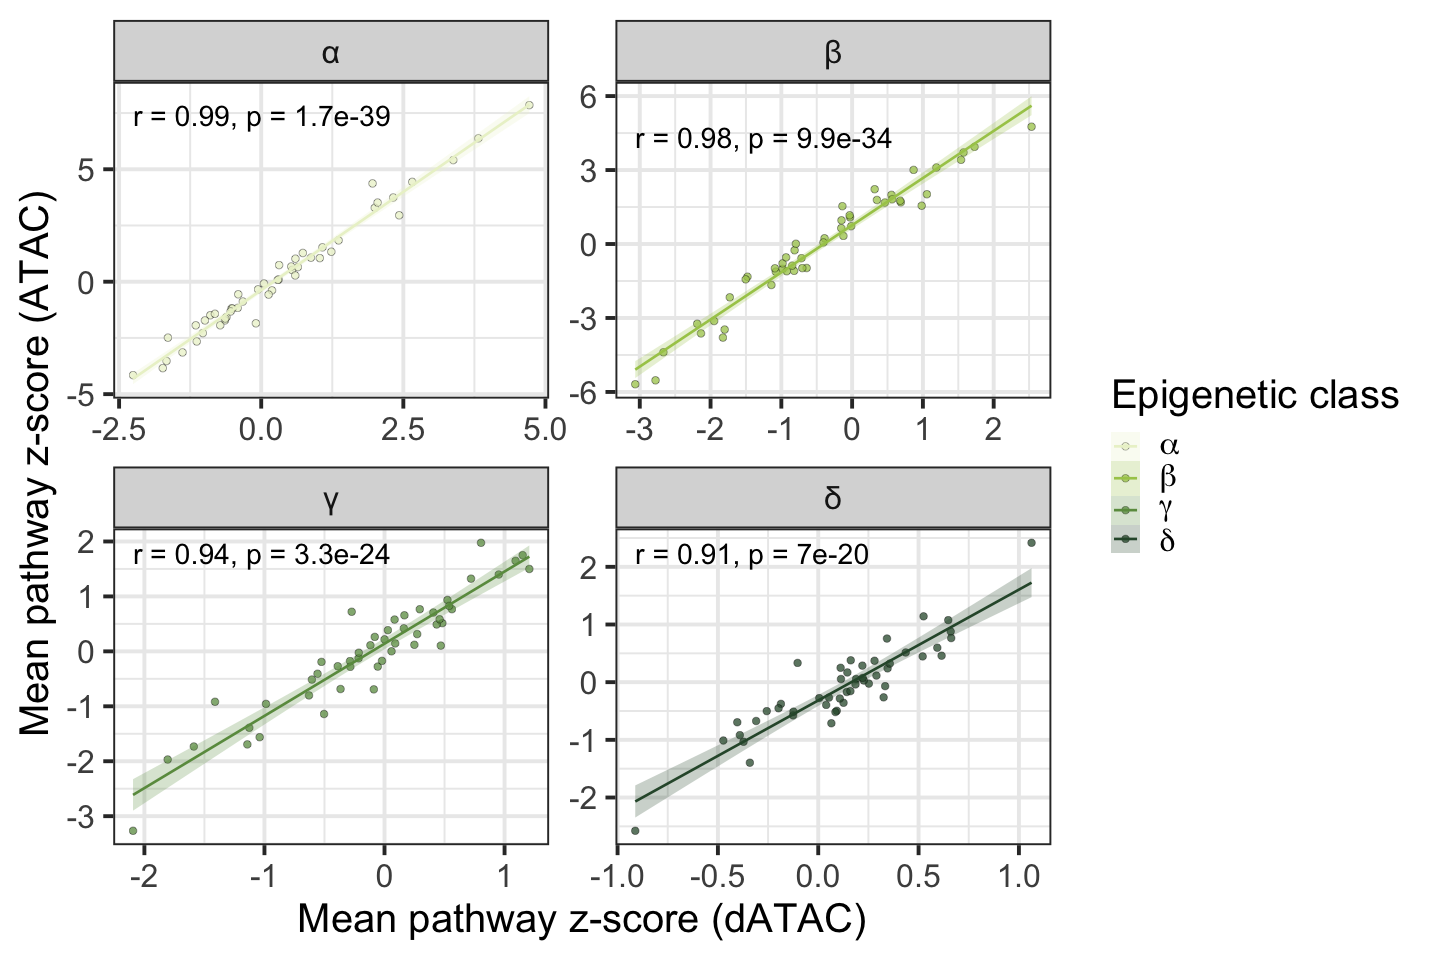

In [8]:
# Comparing ATAC v DATAC epi classes
gsva_a$EpiClass <- pred_epiclass$Epigenetic_Class
mean_all <- c()
for (class in c("α","β","γ","δ")){
  mean_a <- colMeans(gsva_a[gsva_a$EpiClass == class,1:49])
  mean_d <- colMeans(gsva_d[gsva_d$EpiClass == class,1:49])
  mean <- data.frame("Pathway" = colnames(gsva_a[,-50]),
                     "ATAC_mean" = mean_a,
                     "dATAC_mean" = mean_d,
                     "EpiClass" = rep(class,49))
  mean_all <- rbind(mean_all,mean)
 
}
mean_all$EpiClass <- factor(mean_all$EpiClass)

# Obtain correlations between dATAC and ATAC-only classes and their p-values
mean_all_wide <- mean_all %>% tidyr::pivot_wider(names_from = EpiClass,values_from = c(ATAC_mean,dATAC_mean))
corr <- cor(mean_all_wide[,-1])

corr <- c()
p <- c()
Ypos <- c()
Xpos <- c()
for (class in c("α","β","γ","δ")){
  corr <- c(corr, cor.test(mean_all[mean_all$EpiClass == class,]$ATAC_mean,mean_all[mean_all$EpiClass == class,]$dATAC_mean)$estimate)
  p <- c(p,cor.test(mean_all[mean_all$EpiClass == class,]$ATAC_mean,mean_all[mean_all$EpiClass == class,]$dATAC_mean)$p.value)
  Ypos <- c(Ypos, max(mean_all[mean_all$EpiClass == class,]$ATAC_mean))
  Xpos <- c(Xpos, min(mean_all[mean_all$EpiClass == class,]$dATAC_mean))
}

# Create a dataframe to place the correlations and p-values on the figure
corr <- signif(corr,2)
p <- signif(p,2)
text <- data.frame("EpiClass" = sprintf("%s",c("α","β","γ","δ")), 
                   "Text" = sprintf("r = %s, p = %s",corr,p),
                   "Ypos" = Ypos,
                   "XPos" = Xpos)

p1 <- ggplot(mean_all, aes(x = dATAC_mean, y = ATAC_mean, color = EpiClass, fill = EpiClass))+
  geom_point(size = 2, color = "black", alpha = 0.75, shape = 21, stroke = 0.2) +
  stat_smooth(linewidth = 0.75, alpha = 0.25,method = "lm", 
              formula = y ~ x, 
              geom = "smooth") +
   scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  scale_color_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  facet_wrap(vars(EpiClass), nrow = 2, scales = "free")+
  geom_text(data = text, aes(x = Xpos, y = Ypos, label = Text),hjust = 0, vjust = 1,  inherit.aes = FALSE,  size=6) +
  xlab("Mean pathway z-score (dATAC)")+
  ylab("Mean pathway z-score (ATAC)")+
  theme_bw(base_size = 24)

options(repr.plot.width=12, repr.plot.height=8)
p1


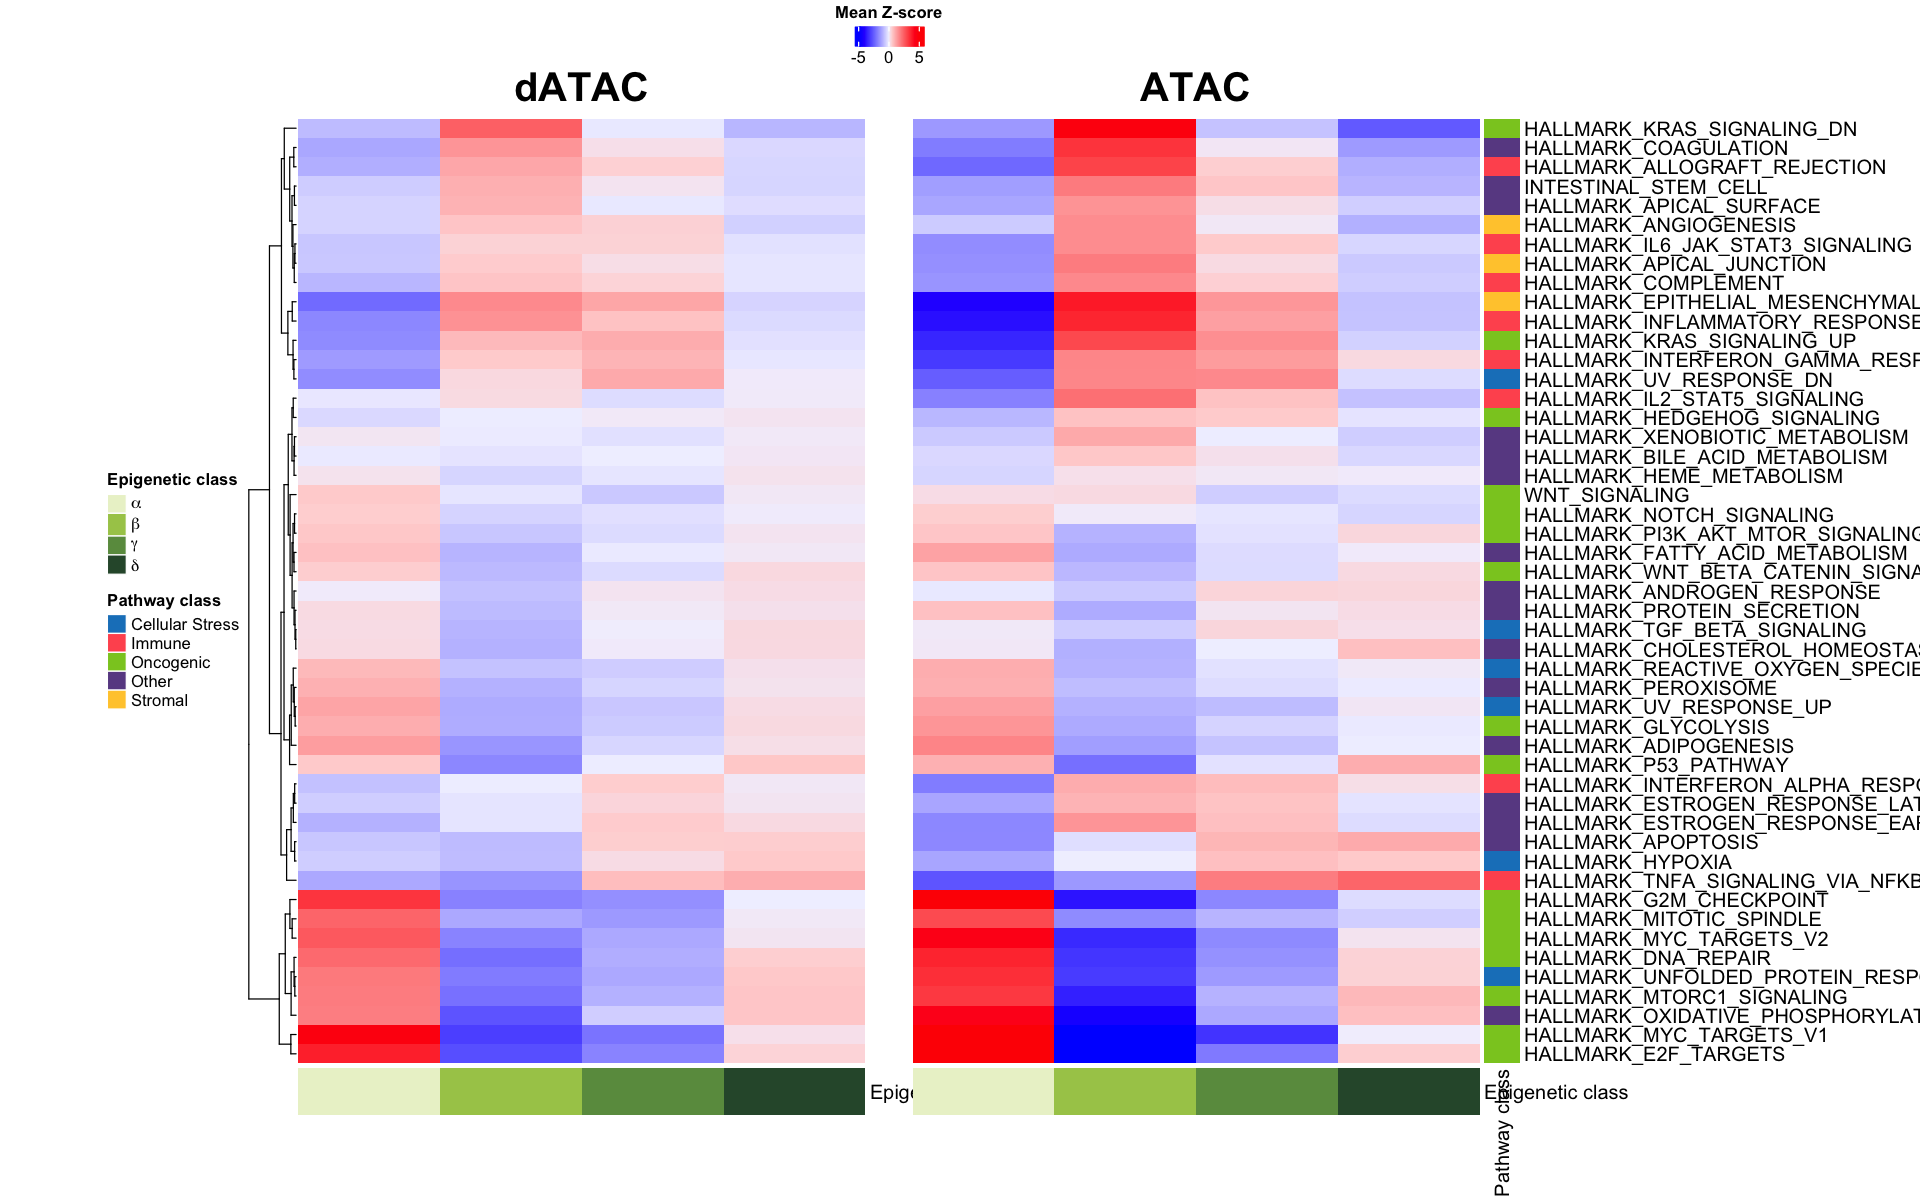

In [9]:
## Heatmap of mean scores ATAC vs dATAC
data <- data.frame(mean_all) %>% dplyr::select(Pathway,ATAC_mean,EpiClass) %>% 
  tidyr::pivot_wider(names_from = EpiClass, values_from = ATAC_mean) 
data <- data.frame(data)
rownames(data) <- data$Pathway
colnames(data) <- c("Pathway",sprintf("Epigenetic class %s",c("α","β","γ","δ")))
data <- data[,-1]

data2 <- data.frame(mean_all) %>% dplyr::select(Pathway,dATAC_mean,EpiClass) %>% 
  tidyr::pivot_wider(names_from = EpiClass, values_from = dATAC_mean) 
data2 <- data.frame(data2)
rownames(data2) <- data2$Pathway
colnames(data2) <- c("Pathway",sprintf("Epigenetic class %s",c("α","β","γ","δ")))
data2 <- data2[,-1]

row_annotation <- data.frame(c("α","β","γ","δ"))
colnames(row_annotation) <- c("Epigenetic class")
rownames(row_annotation) <- colnames(data)



row_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = row_annotation,
                                                      col = list(`Epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                        "\u03B2" = "#a7c957",
                                                                                        "\u03B3" = "#6a994e",
                                                                                        "\u03B4" = "#2f5637")),
                                                      annotation_legend_param = list(
                                                        `Epigenetic class` = list(legend_direction = "horizontal",
                                                                                  at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                  labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta)))),
                                                      simple_anno_size = unit(1, "cm")
)


class_h <- c("Other","Immune","Other",
             "Stromal","Stromal","Other",
             "Other","Other","Other",
             "Other","Immune","Oncogenic",
             "Oncogenic","Stromal","Other",
             "Other","Other","Oncogenic",
             "Oncogenic","Oncogenic","Other",
             "Cellular Stress","Immune","Immune",
             "Immune","Immune","Immune",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Other","Oncogenic",
             "Other","Oncogenic","Other",
             "Cellular Stress","Cellular Stress","Immune",
             "Cellular Stress","Cellular Stress","Cellular Stress",
             "Oncogenic","Other","Oncogenic","Other"
)

column_annotation <- data.frame(class_h)
rownames(column_annotation) <- rownames(data)
colnames(column_annotation) <- c("Pathway class")

column_annotation_h <- ComplexHeatmap::rowAnnotation(df = column_annotation,
                                                     col = list(`Pathway class` = c("Immune" = "#ff595e",
                                                                                    "Stromal" = "#ffca3a",
                                                                                    "Oncogenic" = "#8ac926",
                                                                                    "Cellular Stress" = "#1982c4",
                                                                                    "Other" = "#6a4c93") ),
                                                     simple_anno_size = unit(0.75, "cm")
)



# colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-5, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 5, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

library(ComplexHeatmap)
h <- ComplexHeatmap::Heatmap(as.matrix(((data))), col = colours,
                             show_column_names = FALSE,
                             cluster_columns = FALSE,
                             bottom_annotation = row_annotation_h,
                             right_annotation = column_annotation_h,
                             column_title = "ATAC",
                             column_title_gp = gpar(fontsize = 24, fontface = "bold"),
                             heatmap_legend_param = list(title = "Mean Z-score",legend_direction = "horizontal", title_position = "topcenter"),  
                             width = unit(12,"cm"),
                             height = unit(20,"cm"))


h2 <- ComplexHeatmap::Heatmap(as.matrix(((data2))), col = colours,
                              show_column_names = FALSE,
                              cluster_columns = FALSE,
                              column_title = "dATAC",
                              column_title_gp = gpar(fontsize = 24, fontface = "bold"),
                              bottom_annotation = row_annotation_h,
                              show_heatmap_legend = FALSE,
                              width = unit(12,"cm"),
                              height = unit(20,"cm"))


options(repr.plot.width=16, repr.plot.height=10)

ComplexHeatmap::draw(h2 + h, heatmap_legend_side="top", annotation_legend_side="left", ht_gap = unit(1, "cm"),
                     legend_grouping = "original")


In [10]:
gsva_a <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Consensus_HallmarkPathwayScores_New.csv"))
rownames(gsva_a) <- gsva_a[,1]
gsva_a <- data.frame(gsva_a[,-1])
gsva_a <- t(gsva_a)

# data
data <- as.matrix((gsva_a))
pathways <- rownames(data)


epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")
rownames(epi_classes) <- epi_classes$Cell_id


New names:
• `` -> `...1`
Rows: 5973 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 5973 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, Epigenetic_Class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Setting row names on a tibble is deprecated.”


Rows: 5973 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, Epigenetic_Class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Setting row names on a tibble is deprecated.”
Rows: 5973 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): cell_id
dbl (2): consensus_cluster, stability

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_op

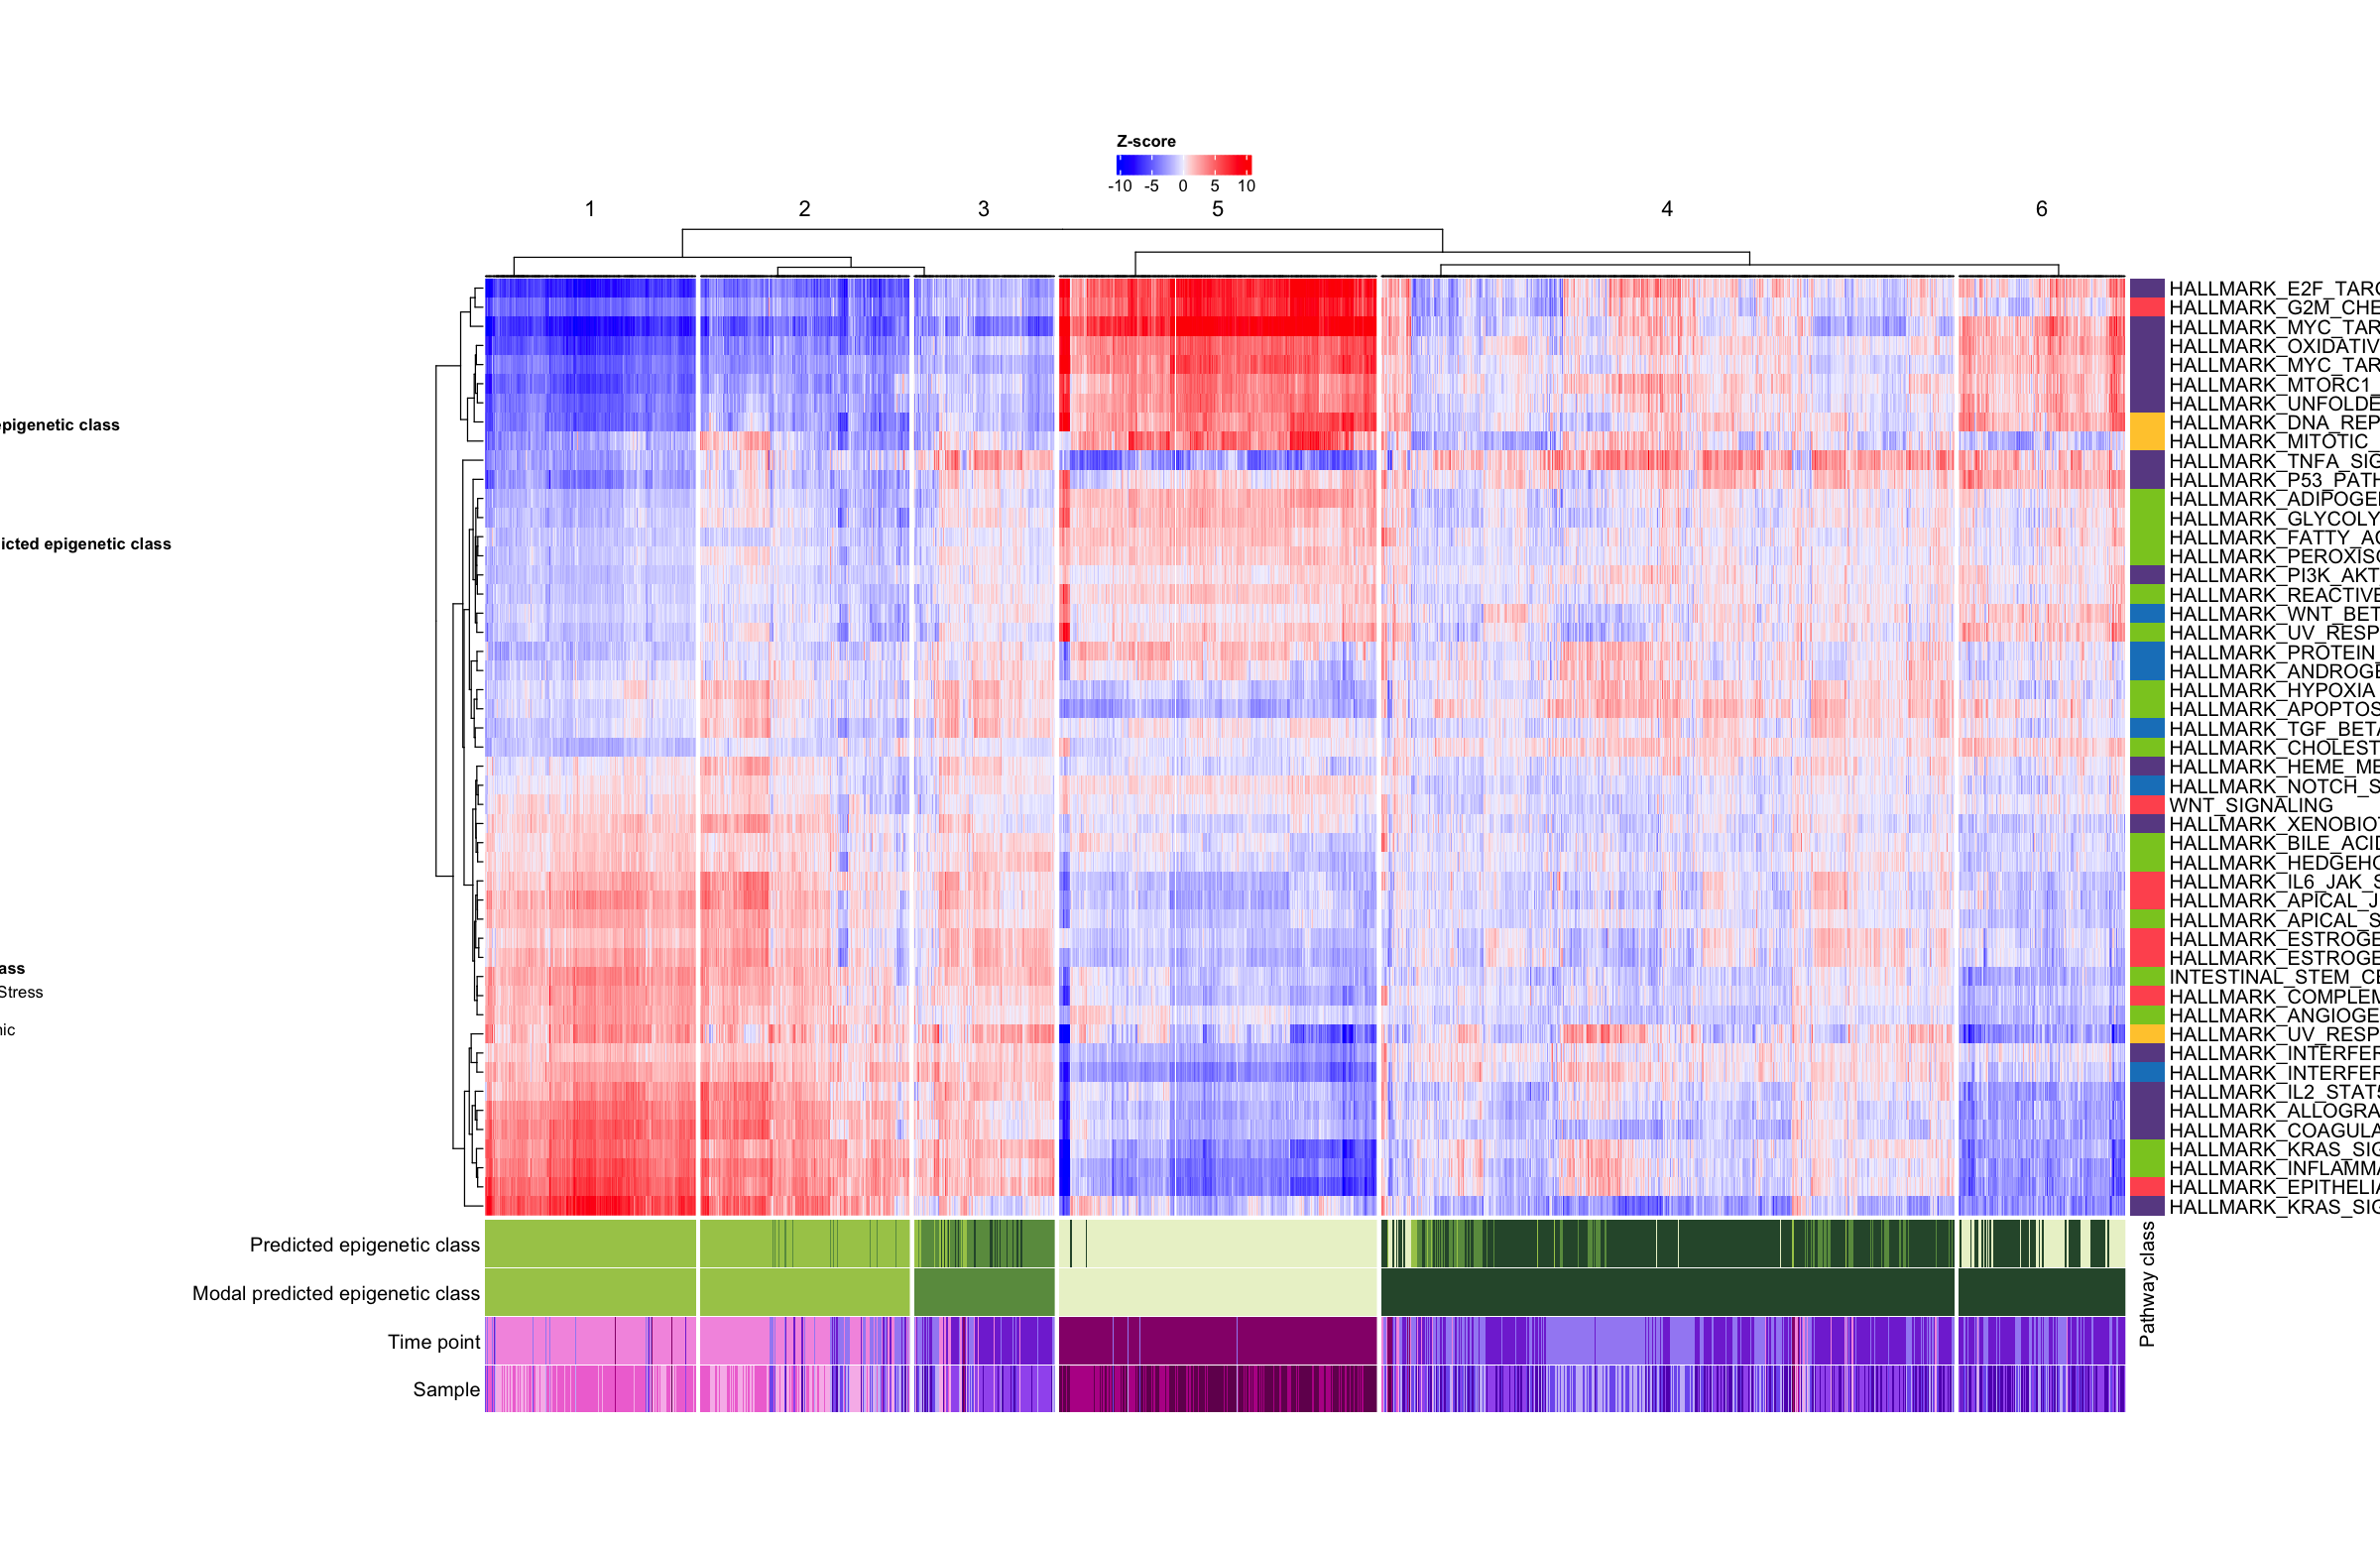

In [15]:
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")
rownames(epi_classes) <- epi_classes$Cell_id

epi_clusters <-  read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Consensus_EpigeneticClasses_New.csv")

epi_classes <- epi_classes[epi_clusters$cell_id,]
data <- data[,epi_clusters$cell_id]


modal_class <- c()
for (class in unique(epi_clusters$consensus_cluster)){
  temp <- epi_clusters[epi_clusters$consensus_cluster == class,]
  cells <- epi_classes[epi_classes$Cell_id %in% temp$cell_id,]$Cell_id
  classes <- epi_classes[epi_classes$Cell_id %in% temp$cell_id,]$Epigenetic_Class
  mode <- rep(names(sort(table(classes), decreasing = TRUE))[1],nrow(temp))
  modal_class <- rbind(modal_class,cbind(cells,mode))
}

modal_class <- data.frame(modal_class)
colnames(modal_class) <- c("Cell_id","ModalEpigeneticClass")
rownames(modal_class) <- modal_class$Cell_id
modal_class <- modal_class[epi_classes$Cell_id,]




# annotations

time <- c()
time[grep("POT",epi_classes$Cell_id)] <- "T0"
time[grep("DSIb|DSIa",epi_classes$Cell_id)] <- "T1"
time[grep("DSIV",epi_classes$Cell_id)] <- "T4"
time[grep("DT1_P1",epi_classes$Cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

sample <- c()
sample[grep("POTa|POTm",epi_classes$Cell_id)] <- "T0.A"
sample[grep("POTb|POTp",epi_classes$Cell_id)] <- "T0.B"
sample[grep("DSIa",epi_classes$Cell_id)] <- "T1.A"
sample[grep("DSIb",epi_classes$Cell_id)] <- "T1.B"
sample[grep("DSIVa",epi_classes$Cell_id)] <- "T4.A"
sample[grep("DSIVb",epi_classes$Cell_id)] <- "T4.B"
sample[grep("DT1_P1a",epi_classes$Cell_id)] <- "T11.A"
sample[grep("DT1_P1b",epi_classes$Cell_id)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))


column_annotation <- data.frame(epi_classes$Epigenetic_Class,modal_class$ModalEpigeneticClass,time,sample)
colnames(column_annotation) <- c("Epigenetic class","Modal epigenetic class","Time point","Sample")
rownames(column_annotation) <- epi_classes$Cell_id



column_annotation <- data.frame(epi_classes$Epigenetic_Class,modal_class$ModalEpigeneticClass,time,sample)
colnames(column_annotation) <- c("Predicted epigenetic class","Modal predicted epigenetic class","Time point","Sample")
rownames(column_annotation) <- epi_classes$Cell_id



column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(`Predicted epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                           "\u03B2" = "#a7c957",
                                                                                           "\u03B3" = "#6a994e",
                                                                                           "\u03B4" = "#2f5637"),
                                                                    `Modal predicted epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                           "\u03B2" = "#a7c957",
                                                                                           "\u03B3" = "#6a994e",
                                                                                           "\u03B4" = "#2f5637"),
                                                                    `Sample` = c("T0.A" = "#730d5d",
                                                                                 "T0.B" = "#b81595",
                                                                                 "T1.A" =  "#f077d6",
                                                                                 "T1.B" =  "#f8bceb",
                                                                                 "T4.A" = "#c9bcf8",
                                                                                 "T4.B" = "#7e60ef",
                                                                                 "T11.A"= "#a25fef",
                                                                                 "T12.B"= "#6113bc"),
                                                                    `Time point` =  c("T0" = "#961179",
                                                                                      "T1" =  "#F49AE1",
                                                                                      "T4" = "#A48EF4",
                                                                                      "T11.5"= "#8239D6")),
                                                         annotation_legend_param = list(
                                                           `Predicted epigenetic class` = list(legend_direction = "horizontal",
                                                                                     at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                     labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta))),
                                                           `Modal predicted epigenetic class` = list(legend_direction = "horizontal",
                                                                                     at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                     labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta))),
                                                           `Time point`= list(legend_direction = "horizontal"),
                                                           `Sample`= list(legend_direction = "horizontal")
                                                         ),
                                                         simple_anno_size = unit(1, "cm"),
                                                         annotation_name_side = "left")


class_h <- c("Other","Immune","Other",
             "Stromal","Stromal","Other",
             "Other","Other","Other",
             "Other","Immune","Oncogenic",
             "Oncogenic","Stromal","Other",
             "Other","Other","Oncogenic",
             "Oncogenic","Oncogenic","Other",
             "Cellular Stress","Immune","Immune",
             "Immune","Immune","Immune",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Other","Oncogenic",
             "Other","Oncogenic","Other",
             "Cellular Stress","Cellular Stress","Immune",
             "Cellular Stress","Cellular Stress","Cellular Stress",
             "Oncogenic","Other","Oncogenic","Other"
)

row_annotation <- data.frame(class_h)
rownames(row_annotation) <- rownames(data)
colnames(row_annotation) <- c("Pathway class")

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Pathway class` = c("Immune" = "#ff595e",
                                                                                 "Stromal" = "#ffca3a",
                                                                                 "Oncogenic" = "#8ac926",
                                                                                 "Cellular Stress" = "#1982c4",
                                                                                 "Other" = "#6a4c93") ),
                                                  simple_anno_size = unit(0.75, "cm")
)



# colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-10, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 10, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

dend <- ComplexHeatmap::cluster_within_group(data,epi_clusters$consensus_cluster)

h <- ComplexHeatmap::Heatmap(as.matrix(((data))), col = colours,
                             show_column_names = FALSE,
                             cluster_columns = dend,
                             column_split = 6,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,
                             heatmap_legend_param = list(title = "Z-score",legend_direction = "horizontal"),
                             raster_quality = 10,
                             width = unit(35,"cm"),
                             height = unit(20,"cm"))


options(repr.plot.width=20, repr.plot.height=13)

ComplexHeatmap::draw(h, heatmap_legend_side="top", annotation_legend_side="left",
                     legend_grouping = "original")


Rows: 668 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 668 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, consensus_cluster
dbl (1): stability

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Setting row names on a tibble is deprecated.”
Rows: 668 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, consensus_cluster
dbl (1): stability

ℹ Use `spec()` to retrieve the full column specification for this da

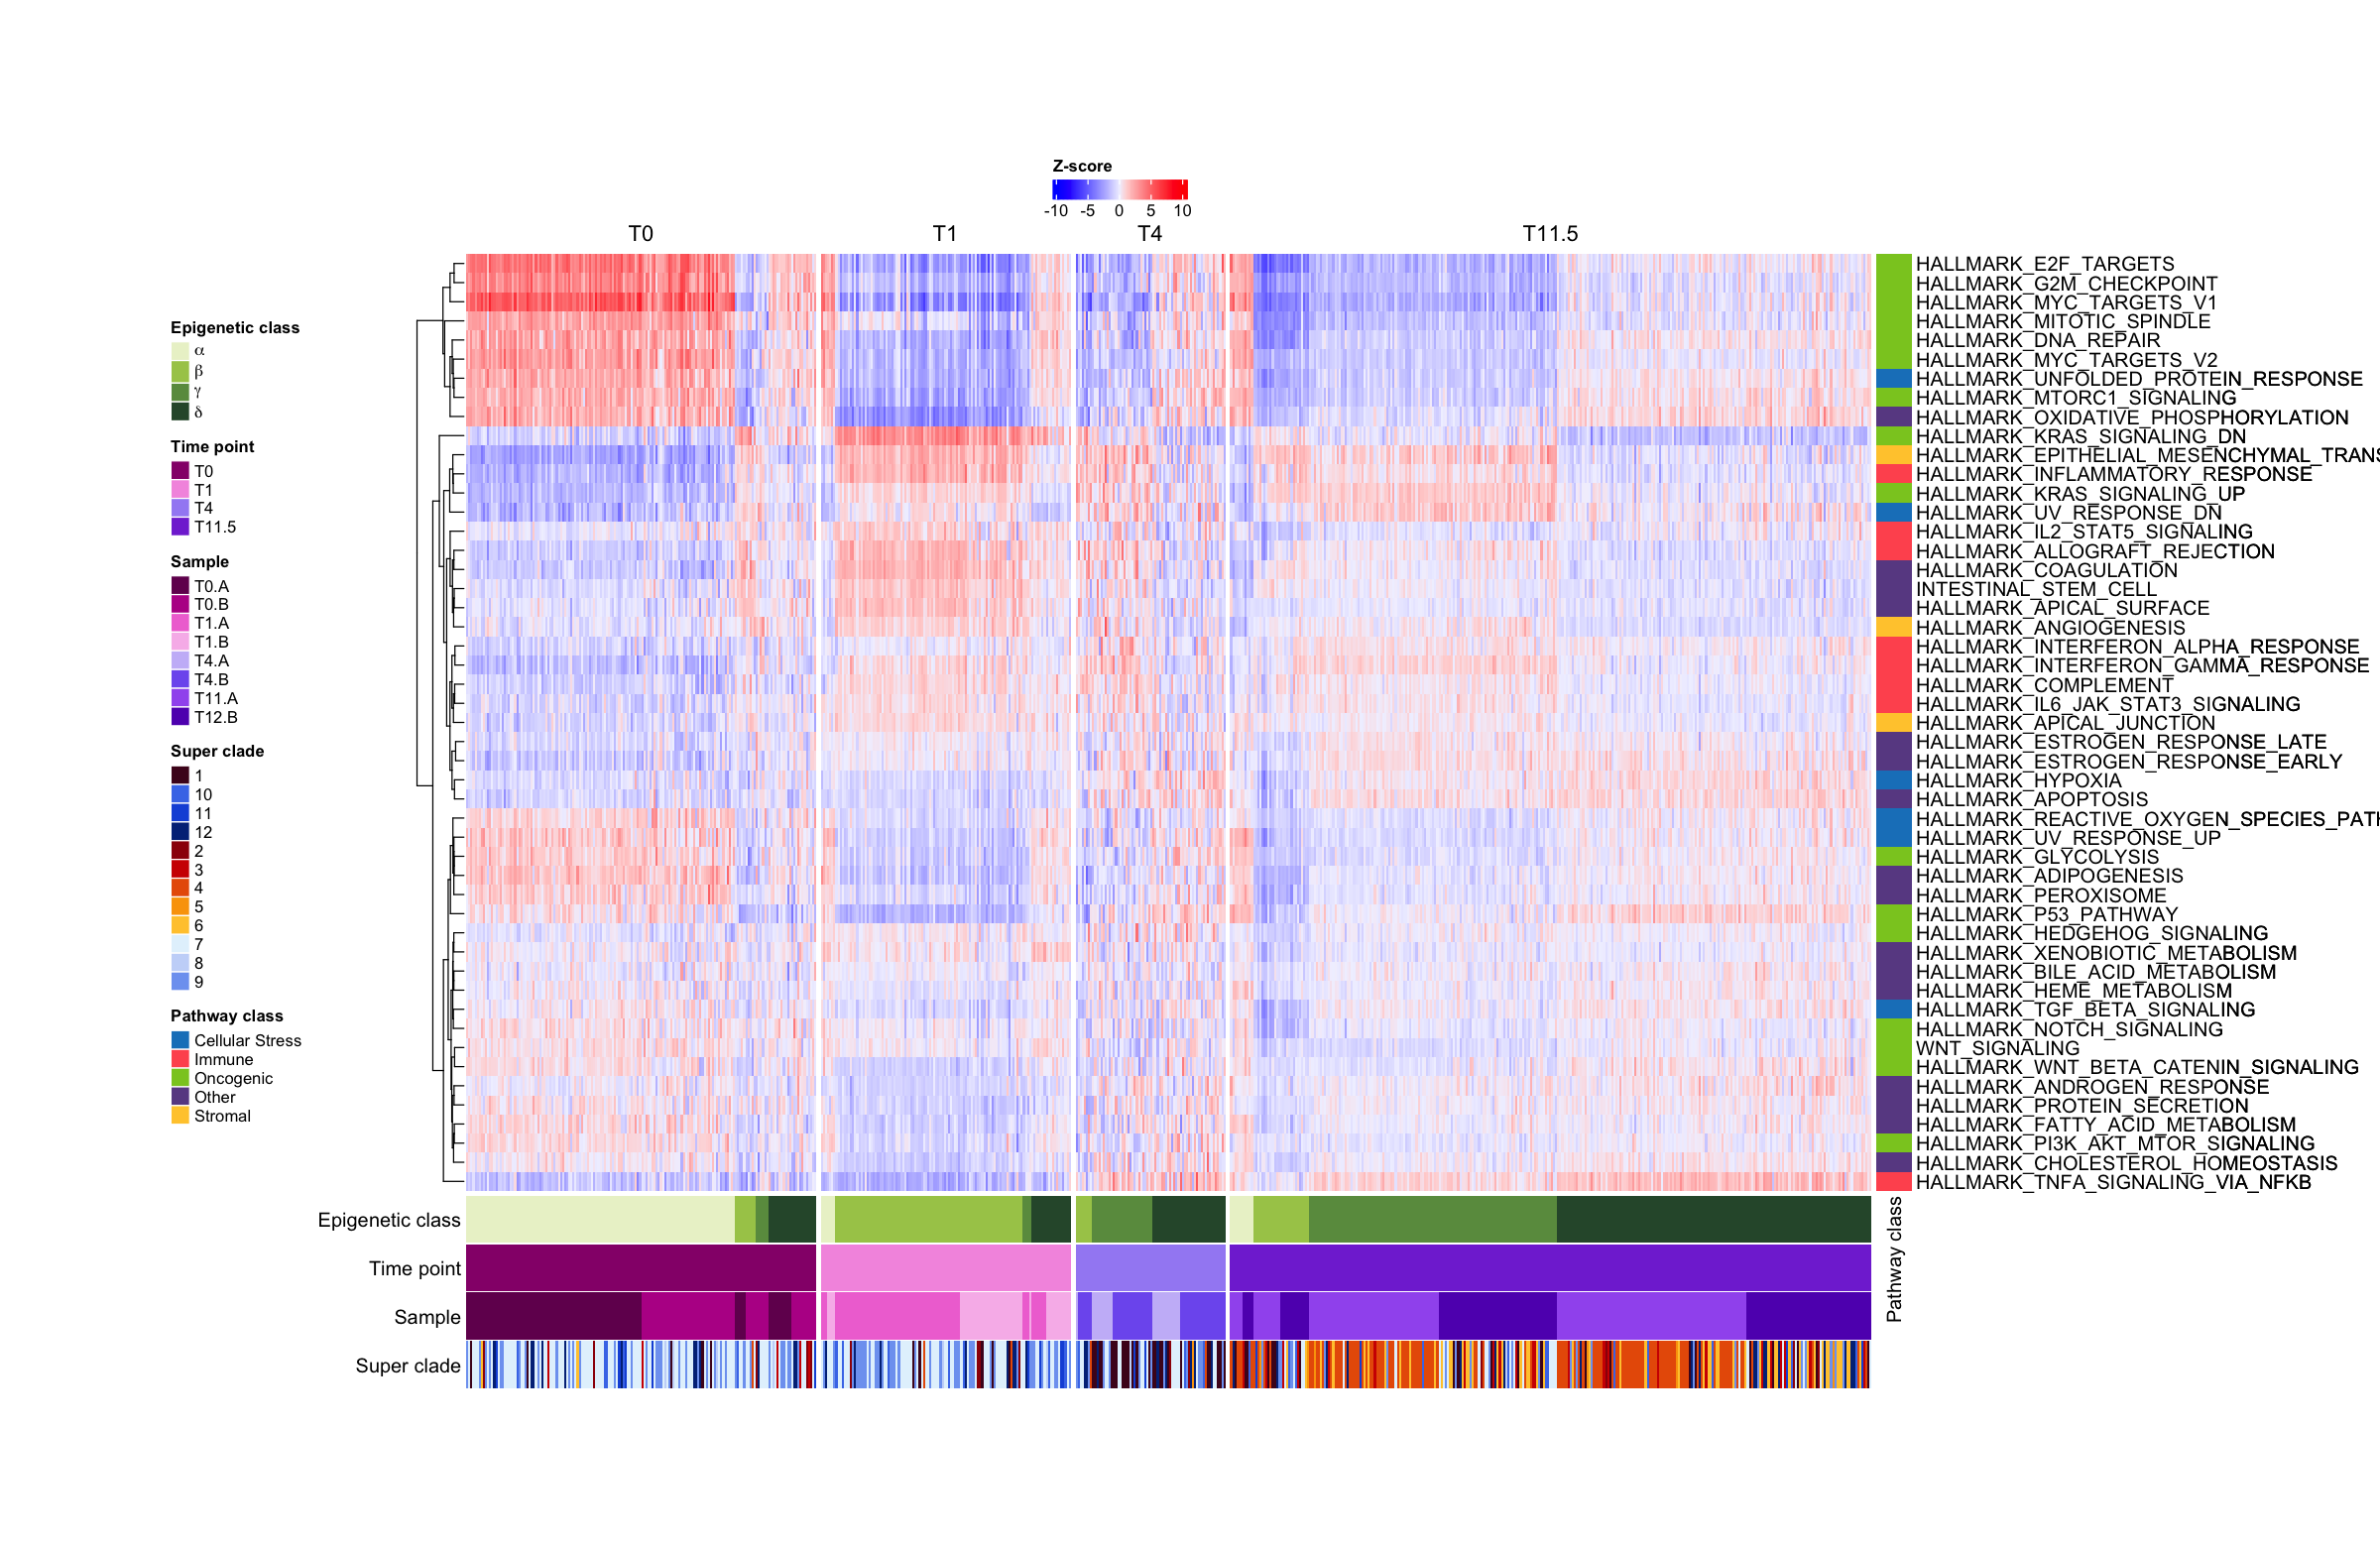

In [13]:
gsva_d <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_HallmarkPathwayScores.csv"))
rownames(gsva_d) <- gsva_d[,1]
gsva_d <- data.frame(gsva_d[,-1])

# data
data <- as.matrix(t(gsva_d))
pathways <- rownames(data)


# sample for ordering
sample <- c()
sample[grep("POTm|POTa",colnames(data))] <- "T0.A"
sample[grep("POTp|POTb",colnames(data))] <- "T0.B"
sample[grep("DSIa",colnames(data))] <- "T1.A"
sample[grep("DSIb",colnames(data))] <- "T1.B"
sample[grep("DSIVa",colnames(data))] <- "T4.A"
sample[grep("DSIVb",colnames(data))] <- "T4.B"
sample[grep("DT1_P1a",colnames(data))] <- "T11.A"
sample[grep("DT1_P1b",colnames(data))] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

time <- c()
time[grep("POT",colnames(data))] <- "T0"
time[grep("DSIb|DSIa",colnames(data))] <- "T1"
time[grep("DSIV",colnames(data))] <- "T4"
time[grep("DT1_P1",colnames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# clusters
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv")
rownames(epi_classes) <- epi_classes$Cell_id
epi_classes <- epi_classes[colnames(data),]

data <- rbind(data,time, epi_classes$consensus_cluster)
data <- data[,order(data[50,],data[51,])]
data <- data[-c(50,51),]

# clusters
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv")
rownames(epi_classes) <- epi_classes$Cell_id
epi_classes <- epi_classes[colnames(data),]

# sample for ordering
sample <- c()
sample[grep("POTm|POTa",colnames(data))] <- "T0.A"
sample[grep("POTp|POTb",colnames(data))] <- "T0.B"
sample[grep("DSIa",colnames(data))] <- "T1.A"
sample[grep("DSIb",colnames(data))] <- "T1.B"
sample[grep("DSIVa",colnames(data))] <- "T4.A"
sample[grep("DSIVb",colnames(data))] <- "T4.B"
sample[grep("DT1_P1a",colnames(data))] <- "T11.A"
sample[grep("DT1_P1b",colnames(data))] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

time <- c()
time[grep("POT",colnames(data))] <- "T0"
time[grep("DSIb|DSIa",colnames(data))] <- "T1"
time[grep("DSIV",colnames(data))] <- "T4"
time[grep("DT1_P1",colnames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))


clades <- data.frame(read_csv("../../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
rownames(clades) <- clades$Cell_id
clade <- clades[colnames(data),]$SuperClade

column_annotation <- data.frame(epi_classes$consensus_cluster,time,sample,clade)
colnames(column_annotation) <- c("Epigenetic class","Time point","Sample","Super clade")
rownames(column_annotation) <- colnames(data)



column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(`Epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                           "\u03B2" = "#a7c957",
                                                                                           "\u03B3" = "#6a994e",
                                                                                           "\u03B4" = "#2f5637"),
                                                                    `Sample` = c("T0.A" = "#730d5d",
                                                                                 "T0.B" = "#b81595",
                                                                                 "T1.A" =  "#f077d6",
                                                                                 "T1.B" =  "#f8bceb",
                                                                                 "T4.A" = "#c9bcf8",
                                                                                 "T4.B" = "#7e60ef",
                                                                                 "T11.A"= "#a25fef",
                                                                                 "T12.B"= "#6113bc"),
                                                                    `Time point` =  c("T0" = "#961179",
                                                                                      "T1" =  "#F49AE1",
                                                                                      "T4" = "#A48EF4",
                                                                                      "T11.5"= "#8239D6"),
                                                                    `Super clade` = c("1" = "#4e0921",
                                                                                     "2" = "#9d0208",
                                                                                     "3" = "#d00000",
                                                                                     "4" = "#e85d04",
                                                                                     "5" = "#faa307",
                                                                                     "6" = "#ffc83b",
                                                                                     "7" = "#e3f2fd",
                                                                                     "8" = "#c8d7f9",
                                                                                     "9" = "#7ea3f1",
                                                                                     "10" = "#487bea",
                                                                                     "11" = "#1957db",
                                                                                     "12" = "#023087")),
                                                         annotation_legend_param = list(
                                                           `Epigenetic class` = list(legend_direction = "horizontal",
                                                                                     at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                     labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta))),
                                                           `Time point`= list(legend_direction = "horizontal"),
                                                           `Sample`= list(legend_direction = "horizontal"),
                                                           `Super clade`= list(legend_direction = "horizontal")
                                                         ),
                                                         simple_anno_size = unit(1, "cm"),
                                                         annotation_name_side = "left")


class_h <- c("Other","Immune","Other",
             "Stromal","Stromal","Other",
             "Other","Other","Other",
             "Other","Immune","Oncogenic",
             "Oncogenic","Stromal","Other",
             "Other","Other","Oncogenic",
             "Oncogenic","Oncogenic","Other",
             "Cellular Stress","Immune","Immune",
             "Immune","Immune","Immune",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Other","Oncogenic",
             "Other","Oncogenic","Other",
             "Cellular Stress","Cellular Stress","Immune",
             "Cellular Stress","Cellular Stress","Cellular Stress",
             "Oncogenic","Other","Oncogenic","Other"
)

row_annotation <- data.frame(class_h)
rownames(row_annotation) <- rownames(data) #sprintf("%s",1:nrow(data))
colnames(row_annotation) <- c("Pathway class")

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Pathway class` = c("Immune" = "#ff595e",
                                                                                 "Stromal" = "#ffca3a",
                                                                                 "Oncogenic" = "#8ac926",
                                                                                 "Cellular Stress" = "#1982c4",
                                                                                 "Other" = "#6a4c93") ),
                                                  simple_anno_size = unit(0.75, "cm")
)



# colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-10, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 10, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

data <- apply(data, 2, as.numeric)
rownames(data) <- pathways

h <- ComplexHeatmap::Heatmap(data, col = colours,
                             show_column_names = FALSE,
                             cluster_columns = FALSE,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,
                             column_split = time,
                             heatmap_legend_param = list(title = "Z-score",legend_direction = "horizontal"),
                             raster_quality = 10,
                             width = unit(30,"cm"),
                             height = unit(20,"cm"))


ComplexHeatmap::draw(h, heatmap_legend_side="top", annotation_legend_side="left",
                     legend_grouping = "original")


ht <- ComplexHeatmap::draw(h, heatmap_legend_side="top", annotation_legend_side="left",
                           legend_grouping = "original")

pathway_order <- ComplexHeatmap::row_order(ht)


New names:
• `` -> `...1`
Rows: 5973 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 5973 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, Epigenetic_Class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Setting row names on a tibble is deprecated.”
Rows: 5973 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, Epigenetic_Class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Speci

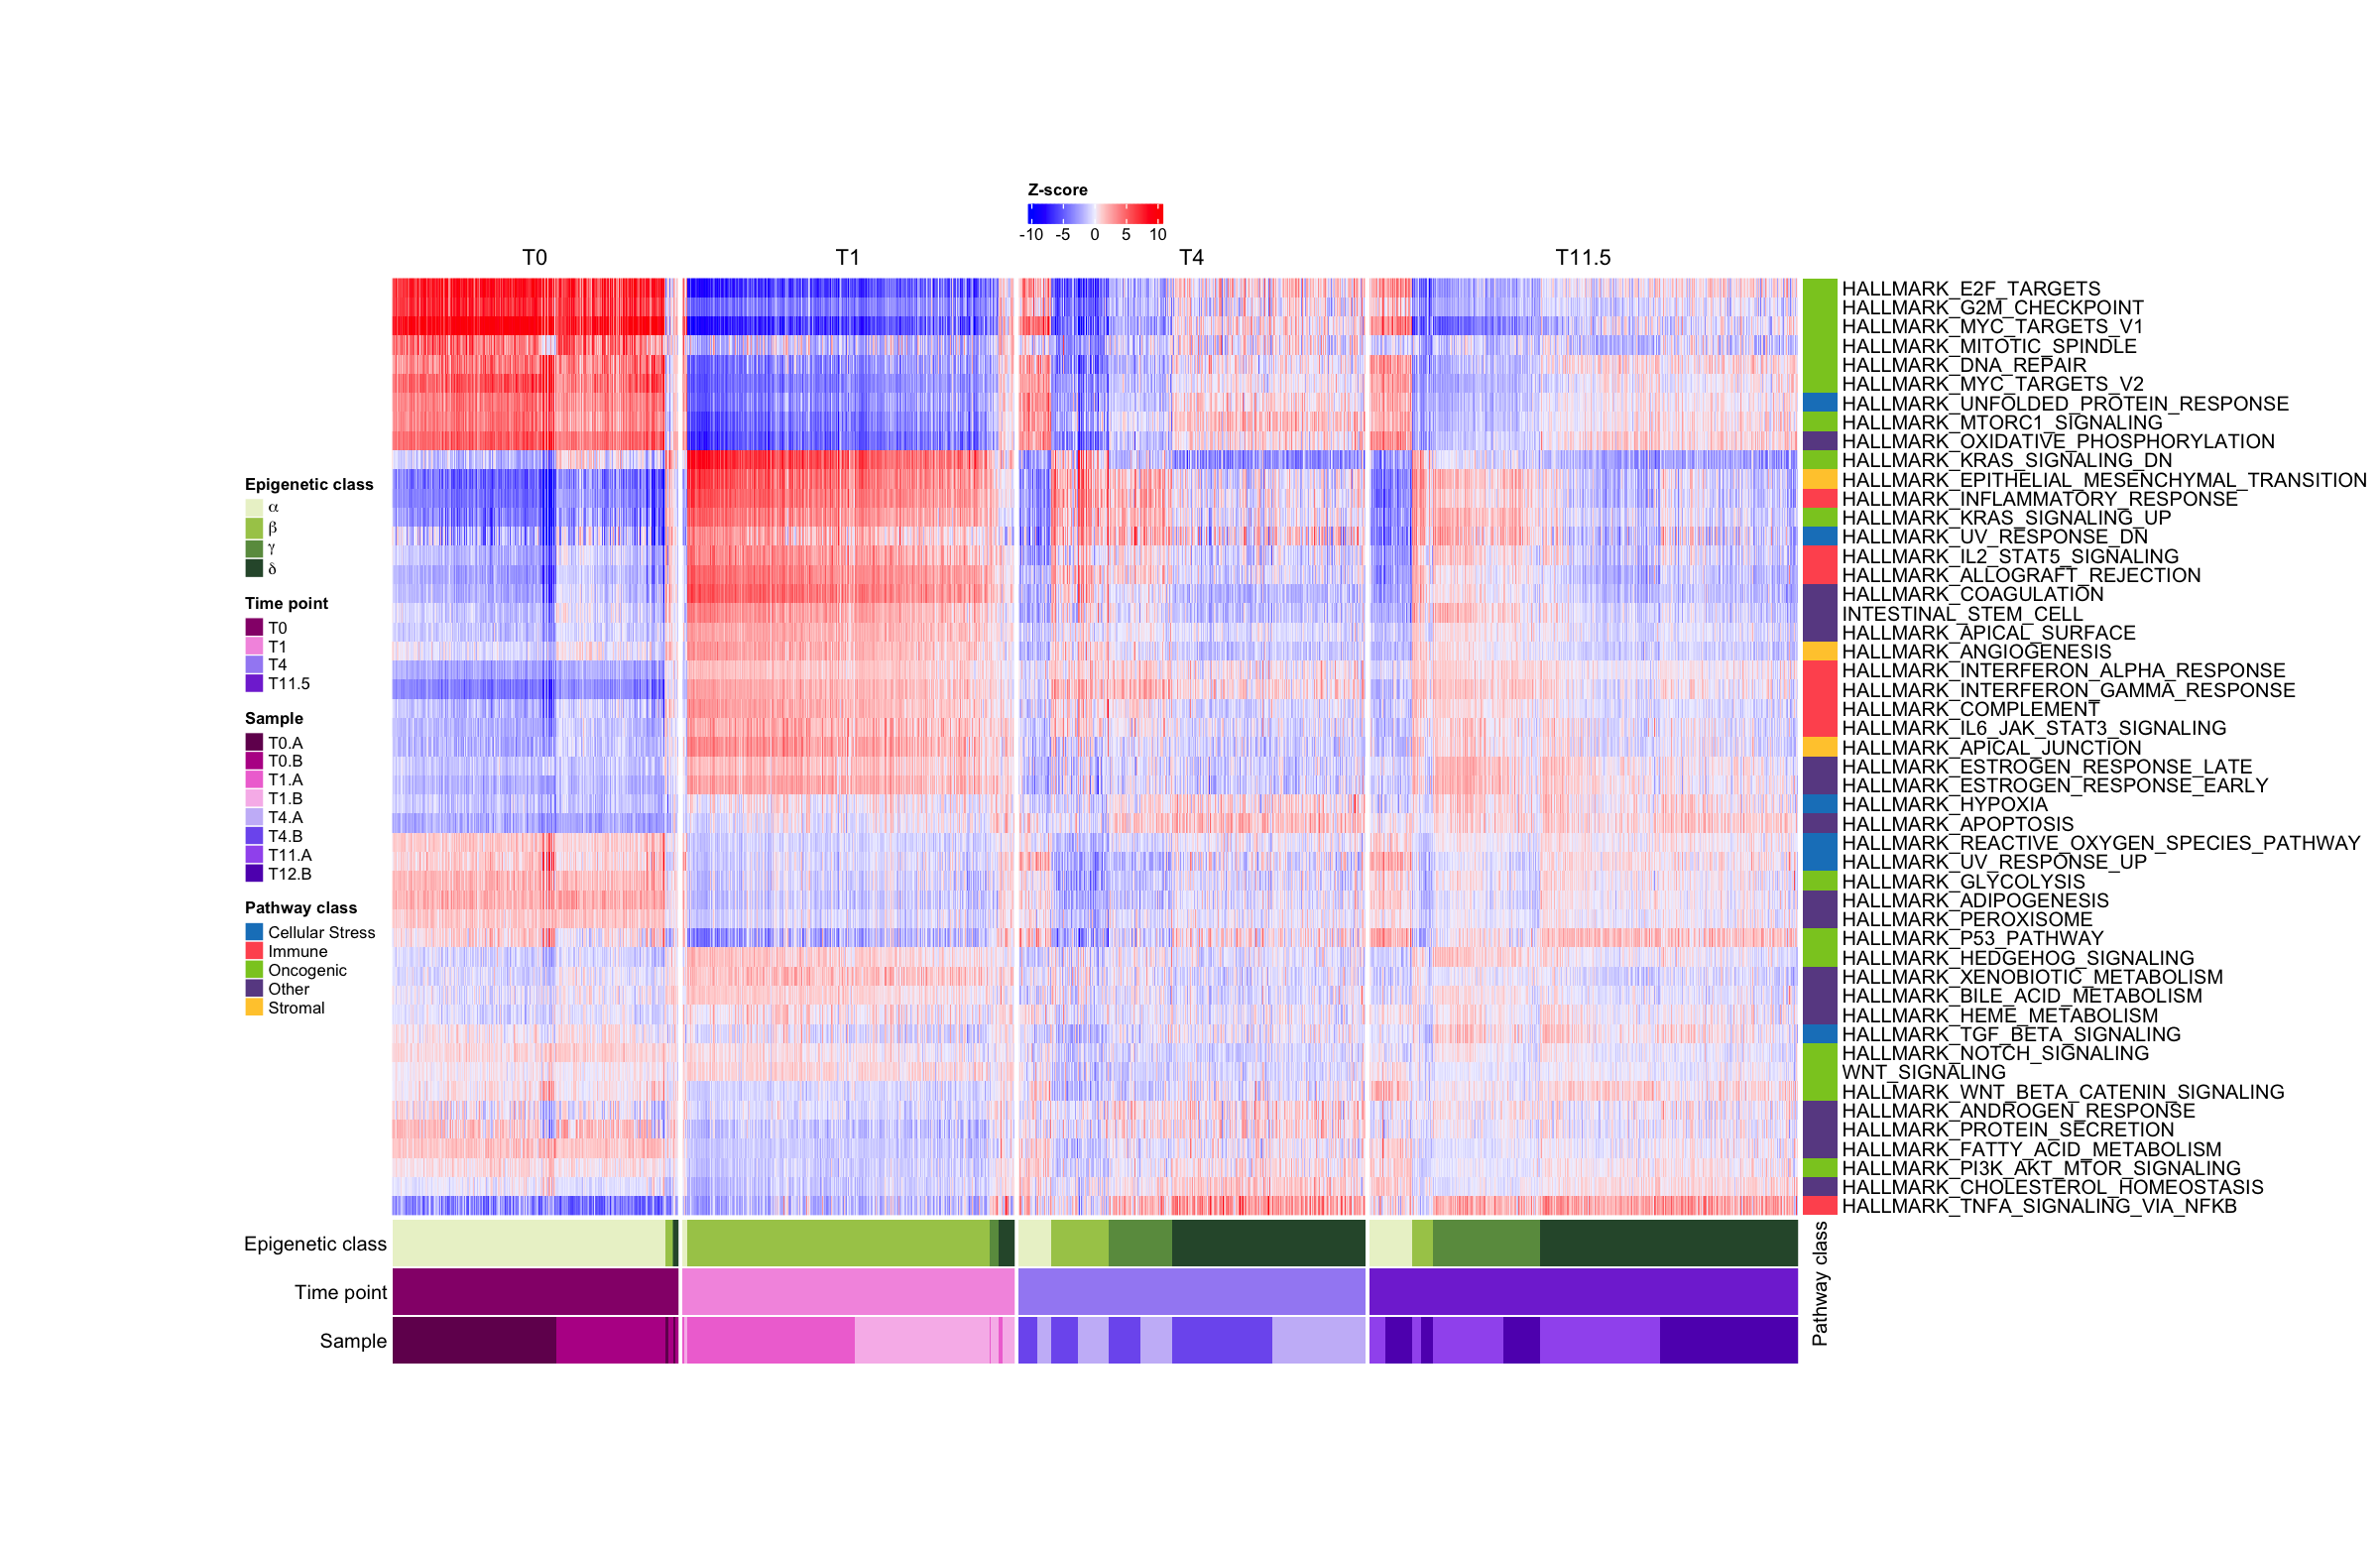

In [14]:
gsva_a <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Consensus_HallmarkPathwayScores_New.csv"))
rownames(gsva_a) <- gsva_a[,1]
gsva_a <- data.frame(gsva_a[,-1])

# data
data <- as.matrix(t(gsva_a))
pathways <- rownames(data)
#rownames(data) <- sprintf("%s",1:nrow(data))


# sample for ordering
sample <- c()
sample[grep("POTm|POTa",colnames(data))] <- "T0.A"
sample[grep("POTp|POTb",colnames(data))] <- "T0.B"
sample[grep("DSIa",colnames(data))] <- "T1.A"
sample[grep("DSIb",colnames(data))] <- "T1.B"
sample[grep("DSIVa",colnames(data))] <- "T4.A"
sample[grep("DSIVb",colnames(data))] <- "T4.B"
sample[grep("DT1_P1a",colnames(data))] <- "T11.A"
sample[grep("DT1_P1b",colnames(data))] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

time <- c()
time[grep("POT",colnames(data))] <- "T0"
time[grep("DSIb|DSIa",colnames(data))] <- "T1"
time[grep("DSIV",colnames(data))] <- "T4"
time[grep("DT1_P1",colnames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# clusters
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")
rownames(epi_classes) <- epi_classes$Cell_id
epi_classes <- epi_classes[colnames(data),]

data <- rbind(data,time, epi_classes$Epigenetic_Class)
data <- data[,order(data[50,],data[51,])]
data <- data[-c(50,51),]

# clusters
epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")
rownames(epi_classes) <- epi_classes$Cell_id
epi_classes <- epi_classes[colnames(data),]

# sample for ordering
sample <- c()
sample[grep("POTm|POTa",colnames(data))] <- "T0.A"
sample[grep("POTp|POTb",colnames(data))] <- "T0.B"
sample[grep("DSIa",colnames(data))] <- "T1.A"
sample[grep("DSIb",colnames(data))] <- "T1.B"
sample[grep("DSIVa",colnames(data))] <- "T4.A"
sample[grep("DSIVb",colnames(data))] <- "T4.B"
sample[grep("DT1_P1a",colnames(data))] <- "T11.A"
sample[grep("DT1_P1b",colnames(data))] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

time <- c()
time[grep("POT",colnames(data))] <- "T0"
time[grep("DSIb|DSIa",colnames(data))] <- "T1"
time[grep("DSIV",colnames(data))] <- "T4"
time[grep("DT1_P1",colnames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))




column_annotation <- data.frame(epi_classes$Epigenetic_Class,time,sample)
colnames(column_annotation) <- c("Epigenetic class","Time point","Sample")
rownames(column_annotation) <- colnames(data)



column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(`Epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                           "\u03B2" = "#a7c957",
                                                                                           "\u03B3" = "#6a994e",
                                                                                           "\u03B4" = "#2f5637"),
                                                                    `Sample` = c("T0.A" = "#730d5d",
                                                                                 "T0.B" = "#b81595",
                                                                                 "T1.A" =  "#f077d6",
                                                                                 "T1.B" =  "#f8bceb",
                                                                                 "T4.A" = "#c9bcf8",
                                                                                 "T4.B" = "#7e60ef",
                                                                                 "T11.A"= "#a25fef",
                                                                                 "T12.B"= "#6113bc"),
                                                                    `Time point` =  c("T0" = "#961179",
                                                                                      "T1" =  "#F49AE1",
                                                                                      "T4" = "#A48EF4",
                                                                                      "T11.5"= "#8239D6")),
                                                         annotation_legend_param = list(
                                                           `Epigenetic class` = list(legend_direction = "horizontal",
                                                                                     at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                     labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta))),
                                                           `Time point`= list(legend_direction = "horizontal"),
                                                           `Sample`= list(legend_direction = "horizontal")
                                                         ),
                                                         simple_anno_size = unit(1, "cm"),
                                                         annotation_name_side = "left")


class_h <- c("Other","Immune","Other",
             "Stromal","Stromal","Other",
             "Other","Other","Other",
             "Other","Immune","Oncogenic",
             "Oncogenic","Stromal","Other",
             "Other","Other","Oncogenic",
             "Oncogenic","Oncogenic","Other",
             "Cellular Stress","Immune","Immune",
             "Immune","Immune","Immune",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Other","Oncogenic",
             "Other","Oncogenic","Other",
             "Cellular Stress","Cellular Stress","Immune",
             "Cellular Stress","Cellular Stress","Cellular Stress",
             "Oncogenic","Other","Oncogenic","Other"
)

row_annotation <- data.frame(class_h)
rownames(row_annotation) <- rownames(data) #sprintf("%s",1:nrow(data))
colnames(row_annotation) <- c("Pathway class")


data <- data[pathway_order,]
row_annotation <- data.frame(`Pathway class` = row_annotation[pathway_order,])
colnames(row_annotation) <- c("Pathway class")
rownames(row_annotation) <- pathways[pathway_order]

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Pathway class` = c("Immune" = "#ff595e",
                                                                                 "Stromal" = "#ffca3a",
                                                                                 "Oncogenic" = "#8ac926",
                                                                                 "Cellular Stress" = "#1982c4",
                                                                                 "Other" = "#6a4c93") ),
                                                  simple_anno_size = unit(0.75, "cm")
)



# colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-10, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 10, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

data <- apply(data, 2, as.numeric)
rownames(data) <- pathways[pathway_order]

h <- ComplexHeatmap::Heatmap(data, col = colours,
                             show_column_names = FALSE,
                             cluster_columns = FALSE,
                             cluster_rows = FALSE,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,
                             column_split = time,
                             heatmap_legend_param = list(title = "Z-score",legend_direction = "horizontal"),
                             raster_quality = 10,
                             width = unit(30,"cm"),
                             height = unit(20,"cm"))

ht <- ComplexHeatmap::draw(h, heatmap_legend_side="top", annotation_legend_side="left",
                           legend_grouping = "original")

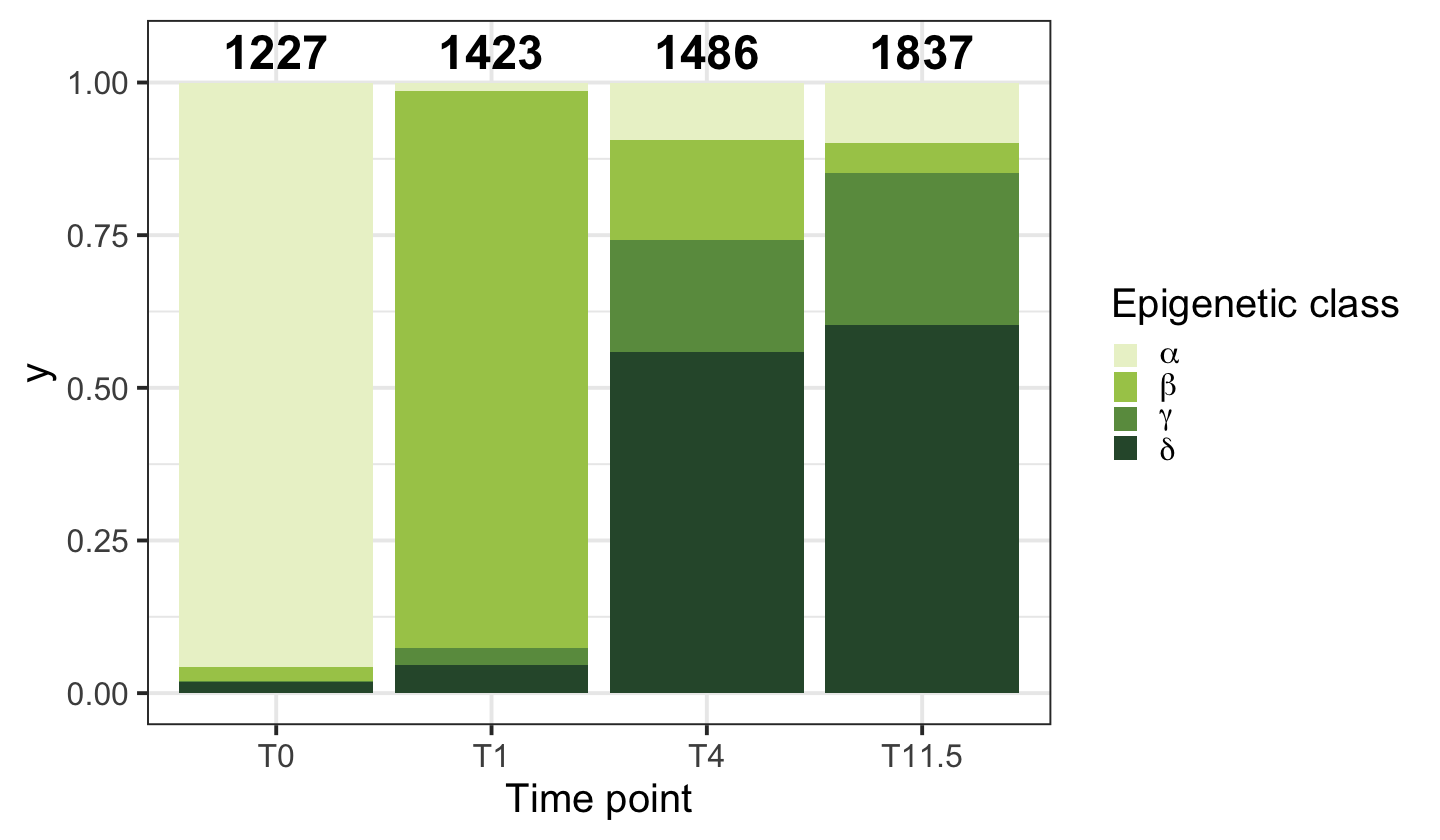

In [16]:
# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv",
                                     col_types = "cc"))
epi_class_names <- epi_classes_df$Cell_id

# Define the time point for each cell in 'epi_class_names'
time <- c()
time[grep("POT",epi_class_names)] <- "T0"
time[grep("DSIb|DSIa",epi_class_names)] <- "T1"
time[grep("DSIV",epi_class_names)] <- "T4"
time[grep("DT1_P1",epi_class_names)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Define the sample for each cell in 'epi_class_names'
sample <- c()
sample[grep("POTa|POTm",epi_class_names)] <- "T0.A"
sample[grep("POTb|POTp",epi_class_names)] <- "T0.B"
sample[grep("DSIa",epi_class_names)] <- "T1.A"
sample[grep("DSIb",epi_class_names)] <- "T1.B"
sample[grep("DSIVa",epi_class_names)] <- "T4.A"
sample[grep("DSIVb",epi_class_names)] <- "T4.B"
sample[grep("DT1_P1a",epi_class_names)] <- "T11.A"
sample[grep("DT1_P1b",epi_class_names)] <-  "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Combine classifications into a dataframe
data <- data.frame("Cell_id" = epi_class_names,
                   "Time" = time,
                   "Sample" = sample,
                   "Epigenetic_Class" = epi_classes_df$Epigenetic_Class)

# Obtain epigenetic class proportions per time
table <- proportions(data = data,obj = "Epigenetic_Class",cat = "Time", subset = F, sub_group = NA, sub_level = NA)

table$Time <- factor(table$Time,levels = c("T0","T1","T4","T11.5"))

counts <- data.frame(table(data$Time))
colnames(counts)[1] <- "Time"


# Plot epigenetic class proportions per time
options(repr.plot.width=12, repr.plot.height=7)

p <- ggplot(table, aes(fill = Epigenetic_Class, x = Time, y = Proportion))+
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  geom_text(data = counts,
            aes(x =`Time`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  geom_bar(position = "fill", stat="identity") +
  xlab("Time point") +
  theme_bw(base_size = 24)
p


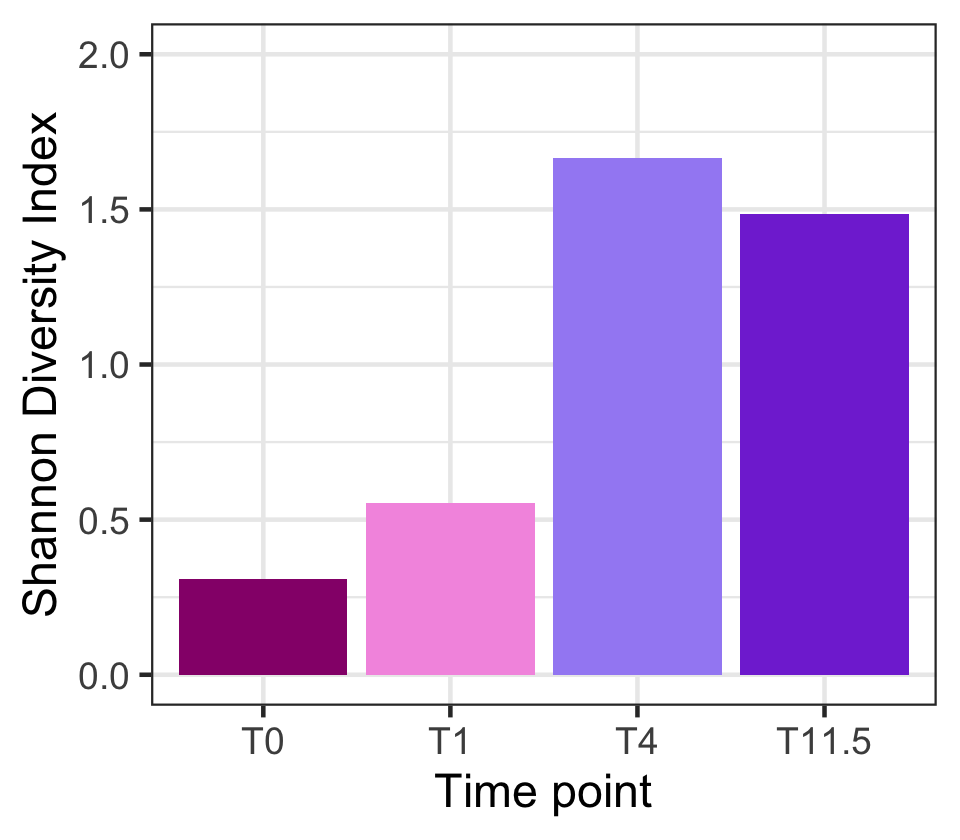

In [17]:
# Compute the Shannon Diversity Index at each time point

shannon_div_t <- c()
for (t in unique(table$Time)){
  shannon_div_t <- c(shannon_div_t,diversity(table[table$Time == t,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div_t <- data.frame(unique(table$Time),
                          shannon_div_t)
colnames(shannon_div_t) <- c("Time","Shannon Diversity Index")
shannon_div_t$Time <- factor(shannon_div_t$Time, levels =  c("T0","T1","T4","T11.5"))

# Plot the Shannon Diversity Index at each time point
options(repr.plot.width=8, repr.plot.height=7)

p <- ggplot(shannon_div_t, aes(fill = `Time`, x = `Time`, y = `Shannon Diversity Index`))+
  scale_fill_manual(name = "Time point",
                    values =  c("T0" = "#961179",
                               "T1" =  "#F49AE1",
                               "T4" = "#A48EF4",
                               "T11.5"= "#8239D6")) +
  geom_bar(stat = "identity") +
  xlab("Time point") +
  guides(fill = "none", color = "none")+
  coord_cartesian(ylim = c(0,2))+
  theme_bw(base_size = 28)

p

In [18]:
# Perform pairwise Hutcheson t-tests to test the significance of the differences between the Shannon diversity at different time points

# Table of the number of cells in each epigenetic class at each time point
table <- abundances(data = data,obj = "Epigenetic_Class",cat = "Time", subset = F, sub_group = NA, sub_level = NA)


# Transform 'table' to obtain columns of abundances for each time point
table_mod  <- table %>% tidyr::pivot_wider(names_from = Time, values_from = Abundance) %>%
                        dplyr::select(- Epigenetic_Class)
 

# Perform the pairwise Hutcheson t-tests
t <- multiple_Hutcheson_t_test(table_mod, shannon.base = 2)

# Print the p-values
t$p.values

,T1 H = 0.56,T11.5 H = 1.48,T0 H = 0.31,T4 H = 1.67
T1 H = 0.56,NA,0,0,0
T11.5 H = 1.48,0,NA,0,0
T0 H = 0.31,0,0,NA,0
T4 H = 1.67,0,0,0,NA


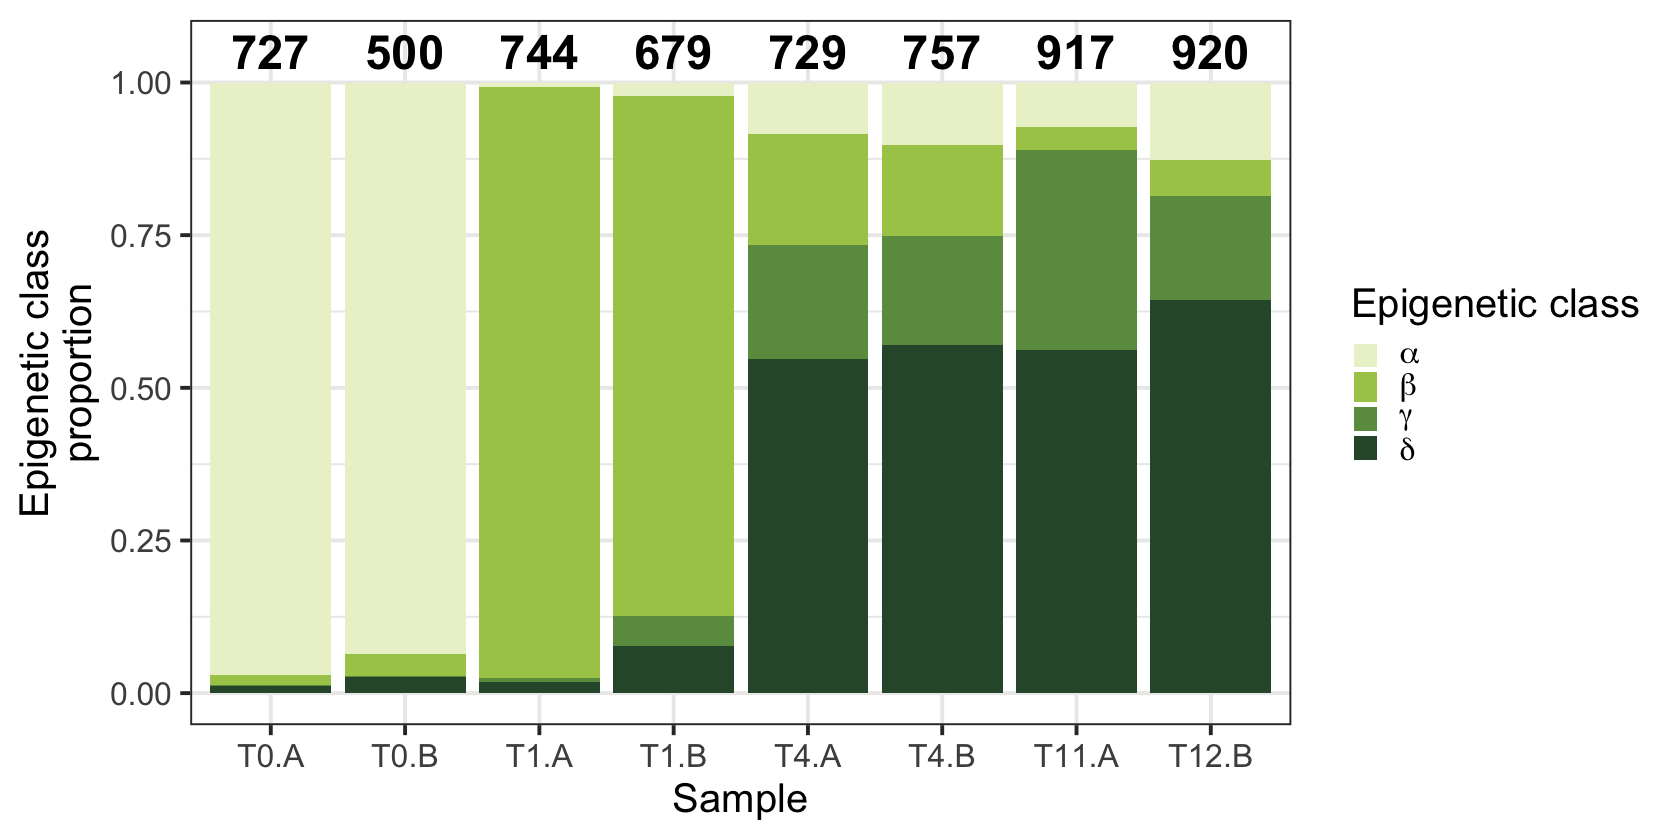

In [19]:
# Obtain epigenetic class proportions per sample
table <- proportions(data = data,obj = "Epigenetic_Class",cat = "Sample", subset = F, sub_group = NA, sub_level = NA)

table$Proportion <- as.numeric(table$Proportion)
table$Sample <- factor(table$Sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

counts <- data.frame(table(data$Sample))
colnames(counts)[1] <- "Sample"

# Plot epigenetic class proportions per time
options(repr.plot.width=14, repr.plot.height=7)

p <- ggplot(table, aes(fill = Epigenetic_Class, x = Sample, y = Proportion))+
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  geom_text(data = counts,
            aes(x =`Sample`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  geom_bar(position = "fill", stat="identity") +
  xlab("Sample") +
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 24)
p

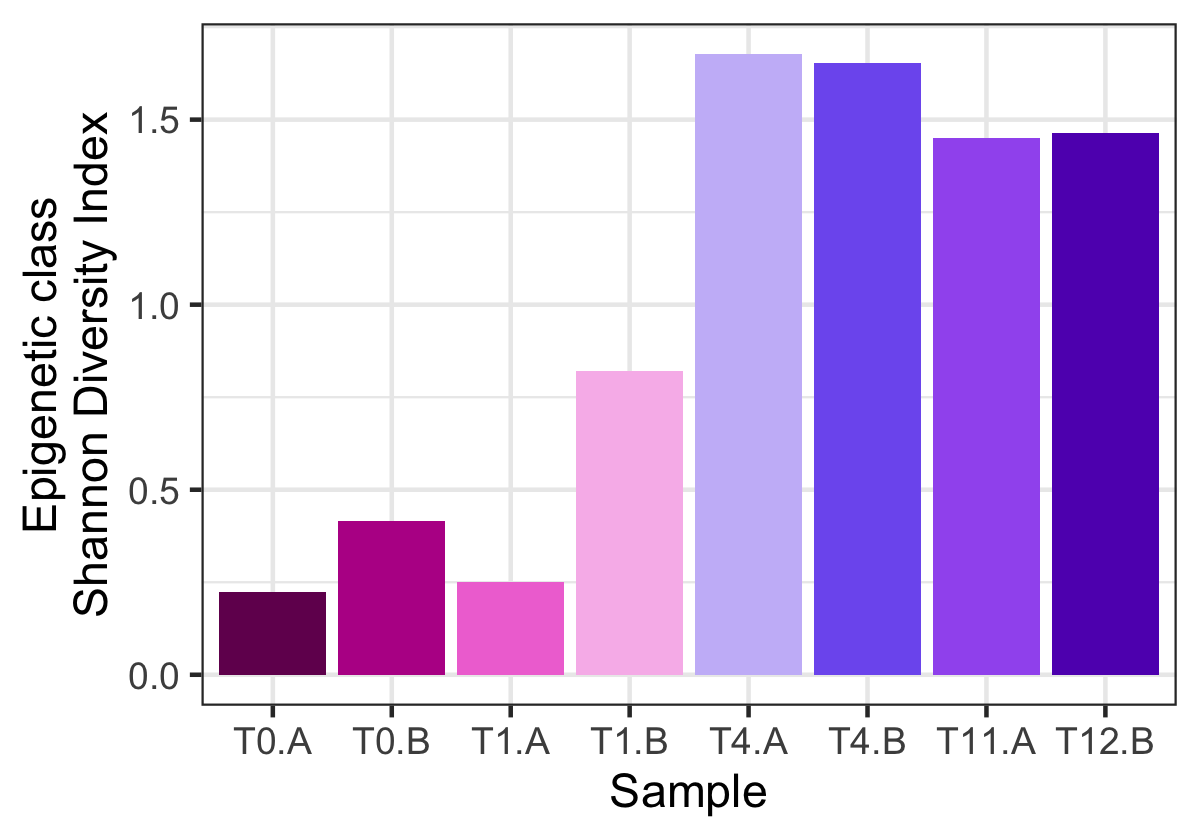

In [20]:
# Compute the Shannon diversity index for each sample
shannon_div <- c()
for (s in c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B")){
  shannon_div <- c(shannon_div,diversity(table[table$Sample == s,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div <- data.frame(c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"),
                          c(shannon_div))
colnames(shannon_div) <- c("Sample","Shannon Diversity Index")
shannon_div$Sample <- factor(shannon_div$Sample, levels =  c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Plot the Shannon diversity index for each sample
options(repr.plot.width=10, repr.plot.height=7)

p <- ggplot(shannon_div, aes(fill = Sample, x = Sample, y = `Shannon Diversity Index`))+
  scale_fill_manual(name = "Time point",
                    values = c("T0.A" = "#730d5d",
                               "T0.B" = "#b81595",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc")) +
  geom_bar(stat = "identity") +
  xlab("Sample") +
  ylab(str_wrap("Epigenetic class Shannon Diversity Index", width = 23))+
  guides(fill = "none", color = "none")+
  theme_bw(base_size = 28)

p

In [21]:
# Perform pairwise Hutcheson t-tests to test the significance of the differences between the Shannon diversity in different samples

# Table of the number of cells in each epigenetic class in each sample
table <- abundances(data = data,obj = "Epigenetic_Class",cat = "Sample", subset = F, sub_group = NA, sub_level = NA)


# Transform 'table' to obtain columns of abundances in each sample
table_mod  <- table %>% tidyr::pivot_wider(names_from = Sample, values_from = Abundance) %>%
                        dplyr::select(- Epigenetic_Class)
 

# Perform the pairwise Hutcheson t-tests
t <- multiple_Hutcheson_t_test(table_mod, shannon.base = 2)

# Print the p-values
t$p.values

,T1.A H = 0.25,T11.A H = 1.45,T12.B H = 1.46,T1.B H = 0.82,T0.A H = 0.22,T0.B H = 0.42,T4.B H = 1.65,T4.A H = 1.68
T1.A H = 0.25,NA,0.00000,0.00000,0,0.32028,0.00821,0.00000,0.00000
T11.A H = 1.45,0.00000,NA,0.39282,0,0.00000,0.00000,0.00002,0.00000
T12.B H = 1.46,0.00000,0.39282,NA,0,0.00000,0.00000,0.00016,0.00002
T1.B H = 0.82,0.00000,0.00000,0.00000,NA,0.00000,0.00000,0.00000,0.00000
T0.A H = 0.22,0.32028,0.00000,0.00000,0,NA,0.00237,0.00000,0.00000
T0.B H = 0.42,0.00821,0.00000,0.00000,0,0.00237,NA,0.00000,0.00000
T4.B H = 1.65,0.00000,0.00002,0.00016,0,0.00000,0.00000,NA,0.32029
T4.A H = 1.68,0.00000,0.00000,0.00002,0,0.00000,0.00000,0.32029,NA


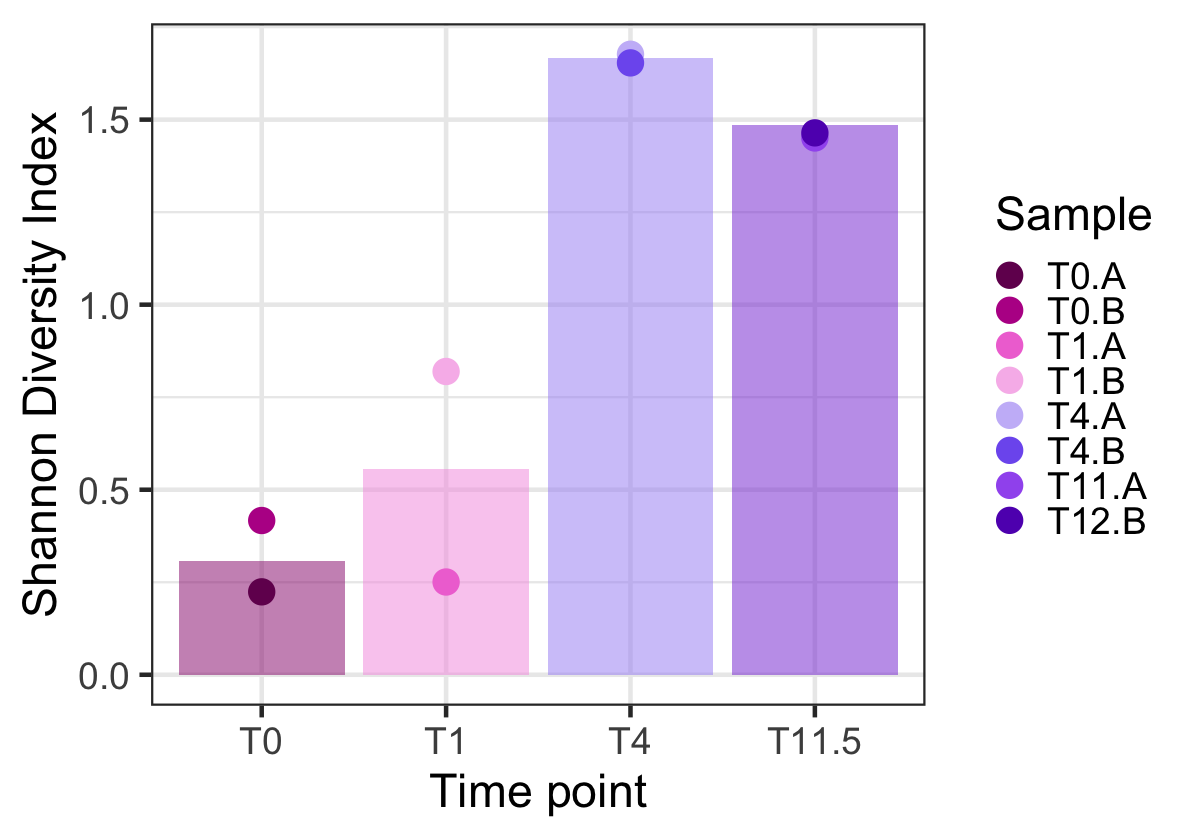

In [22]:
# Plot the Shannon diversity index per time point and sample on one graph

# Obtain epigenetic class proportions per time
table <- proportions(data = data,obj = "Epigenetic_Class",cat = "Time", subset = F, sub_group = NA, sub_level = NA)

table$Time <- factor(table$Time,levels = c("T0","T1","T4","T11.5"))

shannon_div_t <- c()
for (t in unique(table$Time)){
  shannon_div_t <- c(shannon_div_t,diversity(table[table$Time == t,]$Proportion, 
                                             index = "shannon",
                                             base = 2)) 
}

shannon_div_t <- data.frame(unique(table$Time),
                            shannon_div_t)
colnames(shannon_div_t) <- c("Time","Shannon Diversity Index")
shannon_div_t$Time <- factor(shannon_div_t$Time, levels =  c("T0","T1","T4","T11.5"))

# Obtain epigenetic class proportions per sample
table <- proportions(data = data,obj = "Epigenetic_Class",cat = "Sample", subset = F, sub_group = NA, sub_level = NA)

# Add in missing replicates

table$Proportion <- as.numeric(table$Proportion)
table$Sample <- factor(table$Sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))


shannon_div <- c()
for (s in c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B")){
  shannon_div <- c(shannon_div,diversity(table[table$Sample == s,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div <- data.frame(c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"),
                          c("T0","T0","T1","T1","T4","T4","T11.5","T11.5"),
                          c(shannon_div))

colnames(shannon_div) <- c("Sample","Time","Shannon Diversity Index")
shannon_div$Time <- factor(shannon_div$Time, levels =  c("T0","T1","T4","T11.5"))
shannon_div$Sample <- factor(shannon_div$Sample, levels =  c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

p <- ggplot()+
  scale_fill_manual(name = "Time point",
                    values =  c("T0" = "#961179",
                                "T1" =  "#F49AE1",
                                "T4" = "#A48EF4",
                                "T11.5"= "#8239D6")) +
  geom_bar(data = shannon_div_t, aes(fill = Time, x = Time, y = `Shannon Diversity Index`), stat = "identity", alpha = 0.5) +
  scale_color_manual(name = "Sample",
                     values = c("T0.A" = "#730d5d",
                                "T0.B" = "#b81595",
                                "T1.A" =  "#f077d6",
                                "T1.B" =  "#f8bceb",
                                "T4.A" = "#c9bcf8",
                                "T4.B" = "#7e60ef",
                                "T11.A"= "#a25fef",
                                "T12.B"= "#6113bc")) +
  geom_point(data = shannon_div, aes(color = Sample, x = Time, y = `Shannon Diversity Index`), size = 6)+
  xlab("Time point") +
  guides(fill = "none")+
  theme_bw(base_size = 28)

p


In [23]:
### Create UMAPs of epigenetic classes in ATAC and dATAC together - show overlap
# Load and format the GSVA pathway z-score matrix

# ATAC data
gsva_a <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATAC_Consensus_HallmarkPathwayScores_New.csv"))
rownames(gsva_a) <- gsva_a[,1]
gsva_a <- data.frame(gsva_a[,-1])


# dATAC data
gsva_d <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_HallmarkPathwayScores.csv"))
rownames(gsva_d) <- gsva_d[,1]
gsva_d <- data.frame(gsva_d[,-1])

gsva <- t(rbind(gsva_d,gsva_a))

# Load epigenetic classes
epi_classes_d <- data.frame(read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                      col_types = "ccd"))
epi_classes_d <- epi_classes_d %>% dplyr::select(-stability) %>% dplyr::rename(Epigenetic_Class = consensus_cluster)

epi_classes_a <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/ATAC/ATACOnly_KNN_EpigeneticClasses_New.csv")

epi_classes_df <- rbind(epi_classes_a, epi_classes_d)
rownames(epi_classes_df) <- epi_classes_df$Cell_id


# Generate UMAP data based on hallmark pathway z-scores
library(umap)
data <- t(as.matrix(gsva))
custom.config <- umap.defaults
custom.config$random_state <- 7
umap.1 <- umap(data, config = custom.config)

New names:
• `` -> `...1`
Rows: 5973 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 668 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (49): HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_ANDR...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 5973 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Cell_id, Epigenetic_Class

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify t

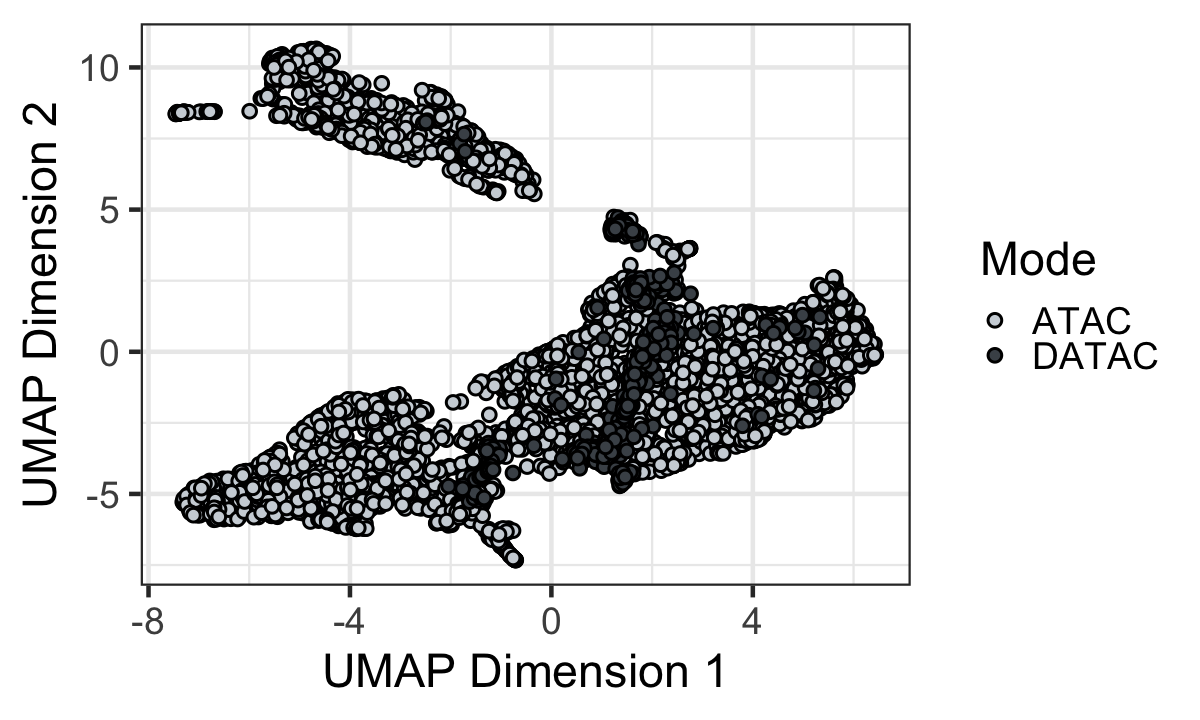

In [24]:
mode <- c()
mode[grep("_ATAC", rownames(data))] <- "ATAC"
mode[grep("_DATAC", rownames(data))] <- "DATAC"

# UMAP plot dataset
plot_umap.1_df <- data.frame(umap.1$layout) %>% 
  dplyr::mutate(Cell_id = rownames(data)) %>% 
  dplyr::mutate(Mode = mode) %>%
  dplyr::mutate(Epigenetic_Class = epi_classes_df[rownames(data),]$Epigenetic_Class)
colnames(plot_umap.1_df) <- c("x","y","Cell_id","Mode","Epigenetic_Class")

write_csv(plot_umap.1_df, "../../Data/ATAC_Data/GeneExpressionScores/Figures/UMAP_HallmarkPathwayScores_ATACvDATAC_New.csv")

plot_umap.1_df$Mode <- factor(plot_umap.1_df$Mode, levels = c("ATAC", "DATAC"))

options(repr.plot.width=10, repr.plot.height=6)

p2 <- ggplot() +
  geom_point(data = plot_umap.1_df[plot_umap.1_df$Mode == "ATAC",],
             aes(x = x, y = y, fill = Mode),
             size = 3, shape = 21, color ="black", alpha = 1) +
  geom_point(data = plot_umap.1_df[plot_umap.1_df$Mode == "DATAC",],
             aes(x = x, y = y, fill = Mode),
             size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Mode",
                    values =  c("ATAC" = "#ced4da",
                                "DATAC" =  "#495057")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  theme_bw(base_size = 28) 
p2